In [1]:
import sys, time
print("HELLO NOTEBOOK", flush=True)
print("python =", sys.executable, flush=True)
time.sleep(1)
print("AFTER 1s", flush=True)


HELLO NOTEBOOK
python = /opt/homebrew/opt/python@3.11/bin/python3.11
AFTER 1s


In [2]:
import sys
!{sys.executable} -m pip install -U duckdb


In [3]:
import duckdb
print("duckdb version:", duckdb.__version__)


duckdb version: 1.4.3


In [4]:
import os
import numpy as np
import pandas as pd

# ====== 输入文件 ======
CSV1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
CSV2 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"

COST_XLSX = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/成本计算/13_park_medical_and_landprice_with_geo_type_maintenance_2024.xlsx"
BASE_SHP  = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"

# ====== 输出文件夹 ======
OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
os.makedirs(OUT_DIR, exist_ok=True)

DUCKDB_PATH   = os.path.join(OUT_DIR, "tmp_payback.duckdb")
PARK_PARQUET  = os.path.join(OUT_DIR, "park_agg.parquet")
USERS_TXT     = os.path.join(OUT_DIR, "approx_unique_users.txt")
OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_table.csv")
OUT_FIG_PNG   = os.path.join(OUT_DIR, "park_payback_map.png")

# ====== 经济参数 ======
YEN_PER_STEP = 0.04
COEF_NUMERATOR = 320000
PAYBACK_HORIZON = 50.0

# ====== 点大小映射参数（可调） ======
SIZE_MIN = 6
SIZE_MAX = 180
SIZE_Q   = 0.99  # 用 sqrt(area) 的 99% 分位做缩放，避免极大公园压扁其他点

# ====== 简单检查 ======
for p in [CSV1, CSV2, COST_XLSX, BASE_SHP]:
    if not os.path.exists(p):
        raise FileNotFoundError(p)

print("OK: all input paths exist")
print("OUT_DIR =", OUT_DIR)


OK: all input paths exist
OUT_DIR = /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output


In [5]:
import sys
!{sys.executable} -m pip install -U pyarrow


In [4]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import pandas as pd

t0 = time.perf_counter()

# =========================
# 0) PATHS / PARAMS
# =========================
VISIT_FILES = [
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv",
]

COST_XLSX = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/"
    r"成本计算/13_park_medical_and_landprice_with_geo_type_maintenance_2024.xlsx"
)

OUT_DIR = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
)

OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_2019_50y.csv")
OUT_TYPE_SUMMARY_CSV = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_2019_50y_by_type.csv")
OUT_RATE_SUMMARY_CSV = os.path.join(OUT_DIR, "park_discount_rate_sensitivity_summary.csv")
OUT_DIAG_TXT = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_2019_50y_diagnostics.txt")

# 主分析参数
EVAL_YEARS = 50
DISCOUNT_RATES = [0.01, 0.02, 0.04]   # 1%, 2%, 4%
MAIN_RATE = 0.04                      # 地图和主结果默认用 4%

YEN_PER_STEP_2019 = 0.04056
EXPANSION_FACTOR = 134.38
PAYBACK_HORIZON = 50

# 建造成本：2014 年 12000 JPY/m2
CONSTRUCTION_UNIT_COST_2014 = 12000.0

# 若 area 只有一列叫 area，且它其实是 hectare，则改成 True
AREA_IS_HECTARE_WHEN_ONLY_AREA = False

# =========================
# 1) CPI TO CONSTANT 2019 JPY
# =========================
# 注意：
# 你如果后面有最终确认的 CPI 口径，可以只改这里，下面逻辑都不用动
CPI_2003_2015BASE = 97.2

# 2014 若只知道 2010=100 口径，可按 2015=100 近似换算
CPI_2014_2015BASE = 102.8 / 103.6 * 100.0
CPI_2017_2015BASE = 100.4
CPI_2019_2015BASE = 101.8

CONSTRUCTION_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2014_2015BASE
OM_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2003_2015BASE

# =========================
# 2) helpers
# =========================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s

def first_valid(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def numeric_median(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.median()) if len(s) else np.nan

def pick_column(columns, exact_candidates=(), contains_all=(), contains_any=(),
                required=True, label="column"):
    cols = list(columns)
    lower_map = {c.lower(): c for c in cols}

    for cand in exact_candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    for c in cols:
        cl = c.lower()
        ok_all = all(k.lower() in cl for k in contains_all) if contains_all else True
        ok_any = any(k.lower() in cl for k in contains_any) if contains_any else True
        if ok_all and ok_any:
            return c

    if required:
        raise KeyError(f"Cannot find {label}. Available columns:\n{cols}")
    return None

def annuity_factor(r, years):
    return np.sum(1.0 / (1.0 + r) ** np.arange(1, years + 1))

def discounted_payback_year_array(invest_arr, annual_net_arr, r, years):
    """
    输入：
    - invest_arr: 一次性投资 array
    - annual_net_arr: 年净收益 array
    输出：
    - 每个 park 的 discounted payback year
      若 years 内不能回本，则为 np.nan
    """
    discount_factors = 1.0 / (1.0 + r) ** np.arange(1, years + 1)
    cum_disc = annual_net_arr[:, None] * np.cumsum(discount_factors)[None, :]
    hit = cum_disc >= invest_arr[:, None]

    out = np.full(len(invest_arr), np.nan)
    valid = (
        np.isfinite(invest_arr)
        & np.isfinite(annual_net_arr)
        & (annual_net_arr > 0)
        & (invest_arr >= 0)
    )
    any_hit = hit.any(axis=1)
    out[valid & any_hit] = hit[valid & any_hit].argmax(axis=1) + 1
    return out

# =========================
# 3) LOAD VISIT-LEVEL + AGG TO PARK-LEVEL
# =========================
frames = []
for fp in VISIT_FILES:
    if not os.path.exists(fp):
        raise FileNotFoundError(fp)
    tmp = pd.read_csv(fp, low_memory=False)
    tmp["__source_file__"] = os.path.basename(fp)
    frames.append(tmp)

visits = pd.concat(frames, ignore_index=True)
print("visit rows:", f"{len(visits):,}")

osm_col_vis = pick_column(
    visits.columns,
    exact_candidates=["osm_id"],
    contains_all=["osm", "id"],
    label="visit osm_id",
)
steps_col = pick_column(
    visits.columns,
    exact_candidates=["steps"],
    contains_any=["steps", "step"],
    label="visit steps",
)

area_m2_col_vis = None
if "area_m2" in visits.columns:
    area_m2_col_vis = "area_m2"
elif "area" in visits.columns:
    area_m2_col_vis = "area"

park_class_col = "park_class" if "park_class" in visits.columns else None
park_class_name_col = "park_class_name" if "park_class_name" in visits.columns else None

# 经纬度列（给地图用）
lon_col_vis = None
lat_col_vis = None
lon_candidates = [c for c in ["Lng", "lng", "lon", "Lon", "longitude", "Longitude",
                              "park_lng", "park_lon", "target_lng", "centroid_lng"] if c in visits.columns]
lat_candidates = [c for c in ["Lat", "lat", "latitude", "Latitude",
                              "park_lat", "target_lat", "centroid_lat"] if c in visits.columns]
if lon_candidates and lat_candidates:
    lon_col_vis = lon_candidates[0]
    lat_col_vis = lat_candidates[0]

visits["osm_id_norm"] = norm_osm(visits[osm_col_vis])
visits["steps_num"] = pd.to_numeric(visits[steps_col], errors="coerce").fillna(0.0)

if area_m2_col_vis is not None:
    visits["area_m2_tmp"] = pd.to_numeric(visits[area_m2_col_vis], errors="coerce")
    if area_m2_col_vis == "area" and AREA_IS_HECTARE_WHEN_ONLY_AREA:
        visits["area_m2_tmp"] = visits["area_m2_tmp"] * 10000.0
else:
    visits["area_m2_tmp"] = np.nan

agg_dict = {
    "steps_num": "sum",
    "area_m2_tmp": numeric_median,
}
rename_dict = {
    "steps_num": "steps_sum",
    "area_m2_tmp": "area_m2",
}

if park_class_col:
    agg_dict[park_class_col] = first_valid
    rename_dict[park_class_col] = "park_class"
if park_class_name_col:
    agg_dict[park_class_name_col] = first_valid
    rename_dict[park_class_name_col] = "park_class_name"
if lon_col_vis and lat_col_vis:
    agg_dict[lon_col_vis] = numeric_median
    agg_dict[lat_col_vis] = numeric_median
    rename_dict[lon_col_vis] = "Lng"
    rename_dict[lat_col_vis] = "Lat"

parks = (
    visits.dropna(subset=["osm_id_norm"])
    .groupby("osm_id_norm", as_index=False)
    .agg(agg_dict)
    .rename(columns=rename_dict)
)

print("parks after visit aggregation:", f"{len(parks):,}")

# =========================
# 4) LOAD COST FILE
# =========================
if not os.path.exists(COST_XLSX):
    raise FileNotFoundError(COST_XLSX)

cost = pd.read_excel(COST_XLSX, engine="openpyxl")
print("cost rows:", f"{len(cost):,}")

osm_col_cost = pick_column(
    cost.columns,
    exact_candidates=["osm_id"],
    contains_all=["osm", "id"],
    label="cost osm_id",
)

land_total_col = pick_column(
    cost.columns,
    exact_candidates=["land_price_1year"],
    contains_all=["land", "price", "1year"],
    required=False,
    label="land total cost column",
)
if land_total_col is None:
    raise KeyError(
        "找不到 land_price_1year。按你的新逻辑，这里不允许退回到 unit land price × area。"
    )

om_unit_col = pick_column(
    cost.columns,
    exact_candidates=[
        "unit_maintenance_yen_per_m2_2024",
        "unit_maintenance_yen_per_m2",
        "annual_om_unit_yen_per_m2",
        "O&M单价",
        "养护单价",
        "维护单价",
        "管理单价",
    ],
    contains_any=["maintenance", "om", "o&m", "养护", "维护", "管理"],
    label="O&M unit cost column",
)

area_m2_col_cost = None
if "area_m2" in cost.columns:
    area_m2_col_cost = "area_m2"
elif "area" in cost.columns:
    area_m2_col_cost = "area"

cost["osm_id_norm"] = norm_osm(cost[osm_col_cost])
cost["land_price_1year_raw"] = pd.to_numeric(cost[land_total_col], errors="coerce")
cost["om_unit_cost_raw"] = pd.to_numeric(cost[om_unit_col], errors="coerce")

if area_m2_col_cost is not None:
    cost["area_m2_cost"] = pd.to_numeric(cost[area_m2_col_cost], errors="coerce")
    if area_m2_col_cost == "area" and AREA_IS_HECTARE_WHEN_ONLY_AREA:
        cost["area_m2_cost"] = cost["area_m2_cost"] * 10000.0
else:
    cost["area_m2_cost"] = np.nan

# land_price_1year 直接就是 park 总地价
cost["land_cost_2019"] = cost["land_price_1year_raw"]

# annual O&M 单价：2003 -> 2019
cost["om_unit_cost_2019"] = cost["om_unit_cost_raw"] * OM_TO_2019_FACTOR

cost = cost.drop_duplicates("osm_id_norm", keep="last")

# =========================
# 5) MERGE
# =========================
df = parks.merge(
    cost[
        [
            "osm_id_norm",
            "land_cost_2019",
            "om_unit_cost_raw",
            "om_unit_cost_2019",
            "area_m2_cost",
        ]
    ],
    on="osm_id_norm",
    how="left",
)

df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")
df["area_m2"] = df["area_m2"].fillna(df["area_m2_cost"])

# =========================
# 6) BENEFIT / COST / NET BENEFIT
# =========================
df["steps_sum"] = pd.to_numeric(df["steps_sum"], errors="coerce").fillna(0.0)

# annual benefit: constant 2019 JPY
df["annual_benefit_yen_2019"] = (
    df["steps_sum"] * YEN_PER_STEP_2019 * EXPANSION_FACTOR
)

# construction cost: 2014 12000 JPY/m2 -> 2019
df["construction_cost_2019"] = (
    df["area_m2"] * CONSTRUCTION_UNIT_COST_2014 * CONSTRUCTION_TO_2019_FACTOR
)

# annual O&M: 2003 source -> 2019, then * area
df["annual_om_cost_2019"] = df["om_unit_cost_2019"] * df["area_m2"]

# annual net benefit
df["annual_net_benefit_2019"] = (
    df["annual_benefit_yen_2019"] - df["annual_om_cost_2019"]
)

# one-time investment
df["one_time_investment_2019"] = (
    df["land_cost_2019"] + df["construction_cost_2019"]
)

# 补充：simple payback（不折现），方便比较
df["simple_payback_years_total"] = np.where(
    (df["annual_net_benefit_2019"] > 0)
    & np.isfinite(df["annual_net_benefit_2019"])
    & np.isfinite(df["one_time_investment_2019"]),
    df["one_time_investment_2019"] / df["annual_net_benefit_2019"],
    np.nan,
)

df["simple_payback_years_land_only"] = np.where(
    (df["annual_net_benefit_2019"] > 0)
    & np.isfinite(df["annual_net_benefit_2019"])
    & np.isfinite(df["land_cost_2019"]),
    df["land_cost_2019"] / df["annual_net_benefit_2019"],
    np.nan,
)

# =========================
# 7) MULTI-RATE DISCOUNTED EVALUATION
# =========================
invest_arr = pd.to_numeric(df["one_time_investment_2019"], errors="coerce").to_numpy(dtype=float)
annual_net_arr = pd.to_numeric(df["annual_net_benefit_2019"], errors="coerce").to_numpy(dtype=float)

rate_summary_rows = []

for r in DISCOUNT_RATES:
    rate_pct = int(round(r * 100))
    rate_tag = f"r{rate_pct}"

    pv_factor = annuity_factor(r, EVAL_YEARS)
    df[f"pv_factor_{rate_tag}"] = pv_factor

    # NPV
    df[f"pv_annual_net_benefit_50y_{rate_tag}"] = df["annual_net_benefit_2019"] * pv_factor
    df[f"npv_50y_{rate_tag}"] = (
        -df["one_time_investment_2019"] + df[f"pv_annual_net_benefit_50y_{rate_tag}"]
    )

    # discounted payback
    payback_arr = discounted_payback_year_array(
        invest_arr=invest_arr,
        annual_net_arr=annual_net_arr,
        r=r,
        years=EVAL_YEARS
    )
    df[f"discounted_payback_years_{rate_tag}"] = payback_arr
    df[f"discounted_payback_status_{rate_tag}"] = np.where(
        df[f"discounted_payback_years_{rate_tag}"].notna(),
        f"recouped within {EVAL_YEARS} years",
        f"not recouped within {EVAL_YEARS} years",
    )

    rate_summary_rows.append({
        "discount_rate": r,
        "discount_rate_pct": rate_pct,
        "pv_factor_50y": pv_factor,
        "recoup_share_50y": df[f"discounted_payback_years_{rate_tag}"].notna().mean(),
        "npv_positive_share": (df[f"npv_50y_{rate_tag}"] > 0).mean(),
        "median_discounted_payback": df[f"discounted_payback_years_{rate_tag}"].median(),
        "mean_discounted_payback": df[f"discounted_payback_years_{rate_tag}"].mean(),
    })

rate_summary = pd.DataFrame(rate_summary_rows)

# 主分析统一映射到 4%
MAIN_RATE_TAG = f"r{int(round(MAIN_RATE * 100))}"
df["payback_years"] = df[f"discounted_payback_years_{MAIN_RATE_TAG}"]
df["discounted_payback_status"] = df[f"discounted_payback_status_{MAIN_RATE_TAG}"]
df["npv_50y_main"] = df[f"npv_50y_{MAIN_RATE_TAG}"]

df["is_black"] = df["payback_years"].isna() | (df["payback_years"] > PAYBACK_HORIZON)
df["payback_clip"] = df["payback_years"].clip(lower=0, upper=PAYBACK_HORIZON)

# =========================
# 8) TYPE-LEVEL SUMMARY
# =========================
type_cols = [c for c in ["park_class", "park_class_name"] if c in df.columns]

type_summary_frames = []
if type_cols:
    for r in DISCOUNT_RATES:
        rate_pct = int(round(r * 100))
        rate_tag = f"r{rate_pct}"

        summary_one = (
            df.groupby(type_cols, dropna=False, as_index=False)
            .agg(
                parks_n=("osm_id_norm", "count"),
                annual_benefit_sum_2019=("annual_benefit_yen_2019", "sum"),
                annual_om_sum_2019=("annual_om_cost_2019", "sum"),
                annual_net_sum_2019=("annual_net_benefit_2019", "sum"),
                investment_sum_2019=("one_time_investment_2019", "sum"),
                npv_50y_sum=(f"npv_50y_{rate_tag}", "sum"),
                recoup_share_50y=(f"discounted_payback_years_{rate_tag}", lambda s: s.notna().mean()),
                median_discounted_payback=(f"discounted_payback_years_{rate_tag}", "median"),
                mean_discounted_payback=(f"discounted_payback_years_{rate_tag}", "mean"),
            )
        )
        summary_one["discount_rate"] = r
        summary_one["discount_rate_pct"] = rate_pct
        type_summary_frames.append(summary_one)

if type_summary_frames:
    type_summary = pd.concat(type_summary_frames, ignore_index=True)
else:
    type_summary = pd.DataFrame()

# =========================
# 9) DIAGNOSTICS
# =========================
benefit_backcheck = np.nan
mask_b = df["steps_sum"] > 0
if mask_b.any():
    benefit_backcheck = np.nanmedian(
        df.loc[mask_b, "annual_benefit_yen_2019"]
        / (df.loc[mask_b, "steps_sum"] * EXPANSION_FACTOR)
    )

match_rate_land = 1 - df["land_cost_2019"].isna().mean()
match_rate_om = 1 - df["om_unit_cost_2019"].isna().mean()
match_rate_area = 1 - df["area_m2"].isna().mean()

diag_lines = []
diag_lines.append(f"visit rows: {len(visits):,}")
diag_lines.append(f"park rows after aggregation: {len(parks):,}")
diag_lines.append(f"final park rows: {len(df):,}")
diag_lines.append("")
diag_lines.append(f"evaluation years: {EVAL_YEARS}")
diag_lines.append(f"discount rates: {DISCOUNT_RATES}")
diag_lines.append(f"main discount rate: {MAIN_RATE:.2%}")
diag_lines.append(f"yen per step (2019 JPY): {YEN_PER_STEP_2019}")
diag_lines.append(f"expansion factor: {EXPANSION_FACTOR}")
diag_lines.append("")
diag_lines.append(f"construction unit cost (2014): {CONSTRUCTION_UNIT_COST_2014:,.2f} JPY/m2")
diag_lines.append(f"construction to 2019 factor: {CONSTRUCTION_TO_2019_FACTOR:.6f}")
diag_lines.append(f"O&M to 2019 factor: {OM_TO_2019_FACTOR:.6f}")
diag_lines.append("")
diag_lines.append(f"match rate land_cost_2019: {match_rate_land:.2%}")
diag_lines.append(f"match rate om_unit_cost_2019: {match_rate_om:.2%}")
diag_lines.append(f"match rate area_m2: {match_rate_area:.2%}")
diag_lines.append("")
diag_lines.append(f"benefit back-check (should be ~{YEN_PER_STEP_2019}): {benefit_backcheck}")
diag_lines.append(f"simple payback total <=50y share: {(df['simple_payback_years_total'] <= EVAL_YEARS).mean():.2%}")
diag_lines.append(f"simple payback land only <=50y share: {(df['simple_payback_years_land_only'] <= EVAL_YEARS).mean():.2%}")

for r in DISCOUNT_RATES:
    rate_pct = int(round(r * 100))
    rate_tag = f"r{rate_pct}"
    diag_lines.append(
        f"discounted payback <=50y share @ {rate_pct}%: "
        f"{df[f'discounted_payback_years_{rate_tag}'].notna().mean():.2%}"
    )
    diag_lines.append(
        f"NPV>0 share @ {rate_pct}%: "
        f"{(df[f'npv_50y_{rate_tag}'] > 0).mean():.2%}"
    )

# =========================
# 10) SAVE
# =========================
ensure_dir(OUT_DIR)

front_cols = [
    "osm_id_norm",
    "park_class",
    "park_class_name",
    "area_m2",
    "steps_sum",
    "annual_benefit_yen_2019",
    "om_unit_cost_raw",
    "om_unit_cost_2019",
    "annual_om_cost_2019",
    "annual_net_benefit_2019",
    "land_cost_2019",
    "construction_cost_2019",
    "one_time_investment_2019",
    "simple_payback_years_total",
    "simple_payback_years_land_only",
    "discounted_payback_years_r1",
    "discounted_payback_years_r2",
    "discounted_payback_years_r4",
    "npv_50y_r1",
    "npv_50y_r2",
    "npv_50y_r4",
    "payback_years",
    "discounted_payback_status",
    "npv_50y_main",
    "is_black",
    "payback_clip",
    "Lng",
    "Lat",
]
keep_cols = [c for c in front_cols if c in df.columns] + [c for c in df.columns if c not in front_cols]
df = df[keep_cols].copy()

df.to_csv(OUT_TABLE_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_TABLE_CSV)

if not type_summary.empty:
    type_summary.to_csv(OUT_TYPE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    print("Saved:", OUT_TYPE_SUMMARY_CSV)

rate_summary.to_csv(OUT_RATE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_RATE_SUMMARY_CSV)

with open(OUT_DIAG_TXT, "w", encoding="utf-8") as f:
    f.write("\n".join(diag_lines))
print("Saved:", OUT_DIAG_TXT)

print("\n".join(diag_lines))
print(f"Cell1 done in {time.perf_counter()-t0:.1f}s")

print("\nRate summary:")
display(rate_summary)

df.head()

visit rows: 1,803,980
parks after visit aggregation: 4,823
cost rows: 5,459
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_2019_50y.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_2019_50y_by_type.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_discount_rate_sensitivity_summary.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_2019_50y_diagnostics.txt
visit rows: 1,803,980
park rows after aggregation: 4,823
final park rows: 4,823

evaluation years: 50
discount rates: [0.01, 0.02, 0.04]
main discount rate: 4.00%
yen per step (2019 JPY): 0.04056
expansion factor: 134.38

construction unit cost (2014): 12,000.00 JPY/m2
construction to 2019 factor: 1.025922
O&M to 2019 factor: 1.047325

match rate land_cost_2019: 99.98%
match rate om_unit_cost_2019: 99.98%
matc

,discount_rate,discount_rate_pct,pv_factor_50y,recoup_share_50y,npv_positive_share,median_discounted_payback,mean_discounted_payback
0,0.01,1,39.196118,0.269334,0.269334,29.0,28.350269
1,0.02,2,31.423606,0.198217,0.198217,26.0,26.845188
2,0.04,4,21.482185,0.112171,0.112171,23.0,23.946396


,osm_id_norm,park_class,park_class_name,area_m2,steps_sum,annual_benefit_yen_2019,om_unit_cost_raw,om_unit_cost_2019,annual_om_cost_2019,annual_net_benefit_2019,...,area_m2_cost,pv_factor_r1,pv_annual_net_benefit_50y_r1,discounted_payback_status_r1,pv_factor_r2,pv_annual_net_benefit_50y_r2,discounted_payback_status_r2,pv_factor_r4,pv_annual_net_benefit_50y_r4,discounted_payback_status_r4
0,100013319,B,Neighborhood Park,8972.0,5917644,3.225384e+07,225.0,235.648148,2.114235e+06,3.013960e+07,...,NaN,39.196118,1.181355e+09,not recouped within 50 years,31.423606,9.470950e+08,not recouped within 50 years,21.482185,6.474645e+08,not recouped within 50 years
1,100225053,C,District Park,39504.0,42525114,2.317811e+08,270.0,282.777778,1.117085e+07,2.206103e+08,...,NaN,39.196118,8.647066e+09,not recouped within 50 years,31.423606,6.932370e+09,not recouped within 50 years,21.482185,4.739191e+09,not recouped within 50 years
2,100490675,A,City block park,1065.0,1988801,1.083987e+07,225.0,235.648148,2.509653e+05,1.058890e+07,...,NaN,39.196118,4.150438e+08,not recouped within 50 years,31.423606,3.327414e+08,not recouped within 50 years,21.482185,2.274727e+08,not recouped within 50 years
3,100606608,C,District Park,37611.0,18432597,1.004660e+08,270.0,282.777778,1.063555e+07,8.983044e+07,...,NaN,39.196118,3.521005e+09,not recouped within 50 years,31.423606,2.822796e+09,not recouped within 50 years,21.482185,1.929754e+09,not recouped within 50 years
4,100606660,D,Comprehensive Park,256984.0,34002034,1.853265e+08,315.0,329.907407,8.478093e+07,1.005456e+08,...,NaN,39.196118,3.940995e+09,not recouped within 50 years,31.423606,3.159504e+09,not recouped within 50 years,21.482185,2.159938e+09,not recouped within 50 years


In [6]:
import time
import duckdb
import os

# 新增：公园聚合输出 CSV（不用 parquet/pyarrow）
PARK_AGG_CSV = os.path.join(OUT_DIR, "park_agg.csv")

t0 = time.perf_counter()
print("DuckDB: start aggregation (CSV + EXACT users)...", flush=True)

con = duckdb.connect(DUCKDB_PATH)

# 多线程（notebook 不开 progress bar，避免 ipywidgets 报错）
con.execute("PRAGMA threads=8;")
con.execute("PRAGMA preserve_insertion_order=false;")

# 统一视图：两份CSV union all
con.execute(f"""
    CREATE OR REPLACE VIEW v AS
    SELECT
        CAST(user_ID AS VARCHAR) AS user_ID,
        CAST(osm_id  AS VARCHAR) AS osm_id,
        CAST(Lat     AS DOUBLE)  AS Lat,
        CAST(Lng     AS DOUBLE)  AS Lng,
        CAST(area    AS DOUBLE)  AS area,
        CAST(steps   AS DOUBLE)  AS steps,
        CAST(park_class_name AS VARCHAR) AS park_class_name
    FROM read_csv_auto('{CSV1}', ignore_errors=true)
    UNION ALL
    SELECT
        CAST(user_ID AS VARCHAR) AS user_ID,
        CAST(osm_id  AS VARCHAR) AS osm_id,
        CAST(Lat     AS DOUBLE)  AS Lat,
        CAST(Lng     AS DOUBLE)  AS Lng,
        CAST(area    AS DOUBLE)  AS area,
        CAST(steps   AS DOUBLE)  AS steps,
        CAST(park_class_name AS VARCHAR) AS park_class_name
    FROM read_csv_auto('{CSV2}', ignore_errors=true);
""")
print("DuckDB: view created", flush=True)

# ——关键修改：精确 distinct user 数（不近似）
# 同时排除空字符串，避免把 "" 当成一个用户
print("DuckDB: counting DISTINCT user_ID (EXACT)...", flush=True)
n_users_exact = con.execute("""
    SELECT COUNT(DISTINCT user_ID) AS n_users
    FROM v
    WHERE user_ID IS NOT NULL AND length(trim(user_ID)) > 0;
""").fetchone()[0]
n_users_exact = int(n_users_exact)
print(f"EXACT unique users = {n_users_exact:,}", flush=True)

with open(USERS_TXT, "w", encoding="utf-8") as f:
    f.write(str(n_users_exact))

# 公园聚合输出 CSV（避免 parquet 依赖）
print("DuckDB: aggregating parks -> CSV ...", flush=True)
con.execute(f"""
    COPY (
        SELECT
            osm_id,
            avg(Lat) AS Lat,
            avg(Lng) AS Lng,
            any_value(area) AS area_m2,
            any_value(park_class_name) AS park_class_name,
            sum(coalesce(steps, 0.0)) AS steps_sum,
            count(*) AS n_visits
        FROM v
        WHERE osm_id IS NOT NULL
          AND Lat IS NOT NULL AND Lng IS NOT NULL
        GROUP BY osm_id
    ) TO '{PARK_AGG_CSV}' (HEADER, DELIMITER ',');
""")

con.close()

print("Wrote users:", USERS_TXT, flush=True)
print("Wrote parks:", PARK_AGG_CSV, flush=True)
print(f"DuckDB done in {time.perf_counter()-t0:.1f}s", flush=True)


DuckDB: start aggregation (CSV + EXACT users)...
DuckDB: view created
DuckDB: counting DISTINCT user_ID (EXACT)...
EXACT unique users = 821,992
DuckDB: aggregating parks -> CSV ...
Wrote users: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/approx_unique_users.txt
Wrote parks: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_agg.csv
DuckDB done in 1.0s


In [51]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import pandas as pd
from IPython.display import display

t0 = time.perf_counter()

# =========================================================
# 0) PATHS / MAIN SETTINGS
# =========================================================
VISIT_FILES = [
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv",
]

COST_XLSX = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/"
    r"成本计算/13_park_medical_and_landprice_with_geo_type_maintenance_2024.xlsx"
)

OUT_DIR = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
)

# 输出文件名：2% 主口径
OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y_main2pct.csv")
OUT_TYPE_SUMMARY_CSV = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y_by_type_main2pct.csv")
OUT_RATE_SUMMARY_CSV = os.path.join(OUT_DIR, "park_discount_rate_sensitivity_fullpayback_summary_main2pct.csv")
OUT_DIAG_TXT = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y_diagnostics_main2pct.txt")

# 主分析：2%，敏感性分析：1% 和 4%
EVAL_YEARS = 50
DISCOUNT_RATES = [0.01, 0.02, 0.04]
MAIN_RATE = 0.02
PAYBACK_HORIZON = 50

# 收益参数
YEN_PER_STEP_2019 = 0.04056
EXPANSION_FACTOR = 150

# 成本参数
CONSTRUCTION_UNIT_COST_2014 = 12000.0
AREA_IS_HECTARE_WHEN_ONLY_AREA = False

# summary 截断
FULL_PAYBACK_CAP_FOR_SUMMARY = 500.0

# =========================================================
# 1) CPI TO CONSTANT 2019 JPY
# =========================================================
CPI_2003_2015BASE = 97.2
CPI_2014_2015BASE = 102.8 / 103.6 * 100.0
CPI_2019_2015BASE = 101.8

CONSTRUCTION_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2014_2015BASE
OM_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2003_2015BASE

# =========================================================
# 2) HELPERS
# =========================================================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s

def first_valid(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def numeric_median(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.median()) if len(s) else np.nan

def pick_column(columns, exact_candidates=(), contains_all=(), contains_any=(),
                required=True, label="column"):
    cols = list(columns)
    lower_map = {c.lower(): c for c in cols}

    for cand in exact_candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    for c in cols:
        cl = c.lower()
        ok_all = all(k.lower() in cl for k in contains_all) if contains_all else True
        ok_any = any(k.lower() in cl for k in contains_any) if contains_any else True
        if ok_all and ok_any:
            return c

    if required:
        raise KeyError(f"Cannot find {label}. Available columns:\n{cols}")
    return None

def rate_tag_from_r(r: float) -> str:
    return f"r{int(round(r * 100))}"

def annuity_factor(r: float, years: int) -> float:
    if r == 0:
        return float(years)
    return float(np.sum(1.0 / (1.0 + r) ** np.arange(1, years + 1)))

def full_payback_year_array(invest_arr, annual_net_arr, r):
    invest = np.asarray(invest_arr, dtype=float)
    annual_net = np.asarray(annual_net_arr, dtype=float)

    out = np.full(len(invest), np.nan, dtype=float)
    valid_base = np.isfinite(invest) & np.isfinite(annual_net)

    # investment <= 0 -> 0
    mask_zero_inv = valid_base & (invest <= 0)
    out[mask_zero_inv] = 0.0

    # investment > 0 and annual_net <= 0 -> never
    mask_never_nonpos_net = valid_base & (invest > 0) & (annual_net <= 0)
    out[mask_never_nonpos_net] = np.inf

    # workable
    mask_work = valid_base & (invest > 0) & (annual_net > 0)
    if not np.any(mask_work):
        return out

    I = invest[mask_work]
    N = annual_net[mask_work]

    if r == 0:
        out[mask_work] = np.ceil(I / N)
        return out

    mask_finite = I < (N / r)
    idx_work = np.where(mask_work)[0]

    idx_never = idx_work[~mask_finite]
    out[idx_never] = np.inf

    if np.any(mask_finite):
        I_fin = I[mask_finite]
        N_fin = N[mask_finite]
        a = r * I_fin / N_fin
        T = np.ceil(-np.log1p(-a) / np.log1p(r))
        idx_fin = idx_work[mask_finite]
        out[idx_fin] = T

    return out

def payback_within_horizon_array(full_payback_arr, years):
    arr = np.asarray(full_payback_arr, dtype=float)
    return np.where(np.isfinite(arr) & (arr <= years), arr, np.nan)

def capped_payback_stats(arr, cap=500.0):
    x = pd.to_numeric(pd.Series(arr), errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return float(np.median(x)), float(np.mean(x))

def finite_mean(s):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def finite_median(s):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def capped_mean(s, cap=500.0):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def capped_median(s, cap=500.0):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

# =========================================================
# 3) LOAD VISIT DATA AND AGGREGATE TO PARK LEVEL
# =========================================================
frames = []
for fp in VISIT_FILES:
    if not os.path.exists(fp):
        raise FileNotFoundError(fp)
    tmp = pd.read_csv(fp, low_memory=False)
    tmp["__source_file__"] = os.path.basename(fp)
    frames.append(tmp)

visits = pd.concat(frames, ignore_index=True)
print("visit rows:", f"{len(visits):,}")

osm_col_vis = pick_column(
    visits.columns,
    exact_candidates=["osm_id"],
    contains_all=["osm", "id"],
    label="visit osm_id",
)
steps_col = pick_column(
    visits.columns,
    exact_candidates=["steps"],
    contains_any=["steps", "step"],
    label="visit steps",
)

area_m2_col_vis = None
if "area_m2" in visits.columns:
    area_m2_col_vis = "area_m2"
elif "area" in visits.columns:
    area_m2_col_vis = "area"

park_class_col = "park_class" if "park_class" in visits.columns else None
park_class_name_col = "park_class_name" if "park_class_name" in visits.columns else None

lon_col_vis = None
lat_col_vis = None
lon_candidates = [c for c in ["Lng", "lng", "lon", "Lon", "longitude", "Longitude",
                              "park_lng", "park_lon", "target_lng", "centroid_lng"] if c in visits.columns]
lat_candidates = [c for c in ["Lat", "lat", "latitude", "Latitude",
                              "park_lat", "target_lat", "centroid_lat"] if c in visits.columns]
if lon_candidates and lat_candidates:
    lon_col_vis = lon_candidates[0]
    lat_col_vis = lat_candidates[0]

visits["osm_id_norm"] = norm_osm(visits[osm_col_vis])
visits["steps_num"] = pd.to_numeric(visits[steps_col], errors="coerce").fillna(0.0)

if area_m2_col_vis is not None:
    visits["area_m2_tmp"] = pd.to_numeric(visits[area_m2_col_vis], errors="coerce")
    if area_m2_col_vis == "area" and AREA_IS_HECTARE_WHEN_ONLY_AREA:
        visits["area_m2_tmp"] = visits["area_m2_tmp"] * 10000.0
else:
    visits["area_m2_tmp"] = np.nan

agg_dict = {
    "steps_num": "sum",
    "area_m2_tmp": numeric_median,
}
rename_dict = {
    "steps_num": "steps_sum",
    "area_m2_tmp": "area_m2",
}

if park_class_col:
    agg_dict[park_class_col] = first_valid
    rename_dict[park_class_col] = "park_class"
if park_class_name_col:
    agg_dict[park_class_name_col] = first_valid
    rename_dict[park_class_name_col] = "park_class_name"
if lon_col_vis and lat_col_vis:
    agg_dict[lon_col_vis] = numeric_median
    agg_dict[lat_col_vis] = numeric_median
    rename_dict[lon_col_vis] = "Lng"
    rename_dict[lat_col_vis] = "Lat"

parks = (
    visits.dropna(subset=["osm_id_norm"])
    .groupby("osm_id_norm", as_index=False)
    .agg(agg_dict)
    .rename(columns=rename_dict)
)
print("parks after visit aggregation:", f"{len(parks):,}")

# =========================================================
# 4) LOAD COST FILE
# =========================================================
if not os.path.exists(COST_XLSX):
    raise FileNotFoundError(COST_XLSX)

cost = pd.read_excel(COST_XLSX, engine="openpyxl")
print("cost rows:", f"{len(cost):,}")

osm_col_cost = pick_column(
    cost.columns,
    exact_candidates=["osm_id"],
    contains_all=["osm", "id"],
    label="cost osm_id",
)

land_total_col = pick_column(
    cost.columns,
    exact_candidates=["land_price_1year"],
    contains_all=["land", "price", "1year"],
    required=False,
    label="land total cost column",
)
if land_total_col is None:
    raise KeyError("找不到 land_price_1year。")

om_unit_col = pick_column(
    cost.columns,
    exact_candidates=[
        "unit_maintenance_yen_per_m2_2024",
        "unit_maintenance_yen_per_m2",
        "annual_om_unit_yen_per_m2",
        "O&M单价",
        "养护单价",
        "维护单价",
        "管理单价",
    ],
    contains_any=["maintenance", "om", "o&m", "养护", "维护", "管理"],
    label="O&M unit cost column",
)

area_m2_col_cost = None
if "area_m2" in cost.columns:
    area_m2_col_cost = "area_m2"
elif "area" in cost.columns:
    area_m2_col_cost = "area"

cost["osm_id_norm"] = norm_osm(cost[osm_col_cost])
cost["land_price_1year_raw"] = pd.to_numeric(cost[land_total_col], errors="coerce")
cost["om_unit_cost_raw"] = pd.to_numeric(cost[om_unit_col], errors="coerce")

if area_m2_col_cost is not None:
    cost["area_m2_cost"] = pd.to_numeric(cost[area_m2_col_cost], errors="coerce")
    if area_m2_col_cost == "area" and AREA_IS_HECTARE_WHEN_ONLY_AREA:
        cost["area_m2_cost"] = cost["area_m2_cost"] * 10000.0
else:
    cost["area_m2_cost"] = np.nan

cost["land_cost_2019"] = cost["land_price_1year_raw"]
cost["om_unit_cost_2019"] = cost["om_unit_cost_raw"] * OM_TO_2019_FACTOR
cost = cost.drop_duplicates("osm_id_norm", keep="last")

# =========================================================
# 5) MERGE
# =========================================================
df = parks.merge(
    cost[
        [
            "osm_id_norm",
            "land_cost_2019",
            "om_unit_cost_raw",
            "om_unit_cost_2019",
            "area_m2_cost",
        ]
    ],
    on="osm_id_norm",
    how="left",
)

df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")
df["area_m2"] = df["area_m2"].fillna(df["area_m2_cost"])

# =========================================================
# 6) BENEFIT / COST / NET BENEFIT
# =========================================================
df["steps_sum"] = pd.to_numeric(df["steps_sum"], errors="coerce").fillna(0.0)

df["annual_benefit_yen_2019"] = df["steps_sum"] * YEN_PER_STEP_2019 * EXPANSION_FACTOR
df["construction_cost_2019"] = df["area_m2"] * CONSTRUCTION_UNIT_COST_2014 * CONSTRUCTION_TO_2019_FACTOR
df["annual_om_cost_2019"] = df["om_unit_cost_2019"] * df["area_m2"]
df["annual_net_benefit_2019"] = df["annual_benefit_yen_2019"] - df["annual_om_cost_2019"]
df["one_time_investment_2019"] = df["land_cost_2019"] + df["construction_cost_2019"]

df["simple_payback_years_total"] = np.where(
    (df["annual_net_benefit_2019"] > 0)
    & np.isfinite(df["annual_net_benefit_2019"])
    & np.isfinite(df["one_time_investment_2019"]),
    df["one_time_investment_2019"] / df["annual_net_benefit_2019"],
    np.nan,
)

df["simple_payback_years_land_only"] = np.where(
    (df["annual_net_benefit_2019"] > 0)
    & np.isfinite(df["annual_net_benefit_2019"])
    & np.isfinite(df["land_cost_2019"]),
    df["land_cost_2019"] / df["annual_net_benefit_2019"],
    np.nan,
)

# =========================================================
# 7) MULTI-RATE EVALUATION
# =========================================================
invest_arr = pd.to_numeric(df["one_time_investment_2019"], errors="coerce").to_numpy(dtype=float)
annual_net_arr = pd.to_numeric(df["annual_net_benefit_2019"], errors="coerce").to_numpy(dtype=float)

rate_summary_rows = []

for r in DISCOUNT_RATES:
    rate_tag = rate_tag_from_r(r)
    rate_pct = int(round(r * 100))

    pv_factor = annuity_factor(r, EVAL_YEARS)
    df[f"pv_factor_50y_{rate_tag}"] = pv_factor

    df[f"pv_annual_net_benefit_50y_{rate_tag}"] = df["annual_net_benefit_2019"] * pv_factor
    df[f"npv_50y_{rate_tag}"] = -df["one_time_investment_2019"] + df[f"pv_annual_net_benefit_50y_{rate_tag}"]

    full_payback_arr = full_payback_year_array(
        invest_arr=invest_arr,
        annual_net_arr=annual_net_arr,
        r=r
    )
    df[f"discounted_payback_years_{rate_tag}"] = full_payback_arr

    within_50_arr = payback_within_horizon_array(full_payback_arr, EVAL_YEARS)
    df[f"discounted_payback_years_50y_{rate_tag}"] = within_50_arr
    df[f"recoup_within_50y_{rate_tag}"] = np.isfinite(within_50_arr)

    full_status = np.full(len(df), "invalid", dtype=object)
    full_status[np.isfinite(full_payback_arr)] = "finite payback"
    full_status[np.isinf(full_payback_arr)] = "never pay back"
    df[f"discounted_payback_status_full_{rate_tag}"] = full_status

    status_50y = np.full(len(df), f"not recouped within {EVAL_YEARS} years", dtype=object)
    status_50y[np.isfinite(within_50_arr)] = f"recouped within {EVAL_YEARS} years"
    status_50y[np.isinf(full_payback_arr)] = "never pay back"
    df[f"discounted_payback_status_50y_{rate_tag}"] = status_50y

    finite_full = pd.Series(full_payback_arr)[np.isfinite(full_payback_arr)]
    median_capped, mean_capped = capped_payback_stats(full_payback_arr, cap=FULL_PAYBACK_CAP_FOR_SUMMARY)

    rate_summary_rows.append({
        "discount_rate": r,
        "discount_rate_pct": rate_pct,
        "pv_factor_50y": pv_factor,
        "recoup_share_50y": float(np.isfinite(within_50_arr).mean()),
        "npv_positive_share": float((df[f"npv_50y_{rate_tag}"] > 0).mean()),
        "never_payback_share": float(np.isinf(full_payback_arr).mean()),
        "median_full_payback_years_finite_only": float(finite_full.median()) if len(finite_full) else np.nan,
        "mean_full_payback_years_finite_only": float(finite_full.mean()) if len(finite_full) else np.nan,
        f"median_full_payback_years_capped{int(FULL_PAYBACK_CAP_FOR_SUMMARY)}": median_capped,
        f"mean_full_payback_years_capped{int(FULL_PAYBACK_CAP_FOR_SUMMARY)}": mean_capped,
        "median_payback_within_50y": float(pd.Series(within_50_arr).median()) if np.isfinite(within_50_arr).any() else np.nan,
        "mean_payback_within_50y": float(pd.Series(within_50_arr).mean()) if np.isfinite(within_50_arr).any() else np.nan,
    })

rate_summary = pd.DataFrame(rate_summary_rows)

# =========================================================
# 8) MAIN RATE MAPPING (2% MAIN)
# =========================================================
MAIN_RATE_TAG = rate_tag_from_r(MAIN_RATE)

df["payback_years"] = df[f"discounted_payback_years_{MAIN_RATE_TAG}"]
df["payback_years_50y"] = df[f"discounted_payback_years_50y_{MAIN_RATE_TAG}"]
df["discounted_payback_status"] = df[f"discounted_payback_status_50y_{MAIN_RATE_TAG}"]
df["npv_50y_main"] = df[f"npv_50y_{MAIN_RATE_TAG}"]

df["is_black"] = (~np.isfinite(df["payback_years"])) | (df["payback_years"] > PAYBACK_HORIZON)

df["payback_clip"] = pd.to_numeric(df["payback_years"], errors="coerce")
df.loc[~np.isfinite(df["payback_clip"]), "payback_clip"] = PAYBACK_HORIZON
df["payback_clip"] = df["payback_clip"].clip(lower=0, upper=PAYBACK_HORIZON)

# =========================================================
# 9) TYPE-LEVEL SUMMARY
# =========================================================
type_cols = [c for c in ["park_class", "park_class_name"] if c in df.columns]

type_summary_frames = []
if type_cols:
    for r in DISCOUNT_RATES:
        rate_tag = rate_tag_from_r(r)
        rate_pct = int(round(r * 100))

        summary_one = (
            df.groupby(type_cols, dropna=False, as_index=False)
            .agg(
                parks_n=("osm_id_norm", "count"),
                annual_benefit_sum_2019=("annual_benefit_yen_2019", "sum"),
                annual_om_sum_2019=("annual_om_cost_2019", "sum"),
                annual_net_sum_2019=("annual_net_benefit_2019", "sum"),
                investment_sum_2019=("one_time_investment_2019", "sum"),
                npv_50y_sum=(f"npv_50y_{rate_tag}", "sum"),
                recoup_share_50y=(f"recoup_within_50y_{rate_tag}", "mean"),
                never_payback_share=(f"discounted_payback_years_{rate_tag}", lambda s: np.isinf(pd.to_numeric(s, errors='coerce')).mean()),
                median_full_payback_years_finite_only=(f"discounted_payback_years_{rate_tag}", finite_median),
                mean_full_payback_years_finite_only=(f"discounted_payback_years_{rate_tag}", finite_mean),
                median_full_payback_years_capped500=(f"discounted_payback_years_{rate_tag}", lambda s: capped_median(s, cap=FULL_PAYBACK_CAP_FOR_SUMMARY)),
                mean_full_payback_years_capped500=(f"discounted_payback_years_{rate_tag}", lambda s: capped_mean(s, cap=FULL_PAYBACK_CAP_FOR_SUMMARY)),
                median_payback_within_50y=(f"discounted_payback_years_50y_{rate_tag}", "median"),
                mean_payback_within_50y=(f"discounted_payback_years_50y_{rate_tag}", "mean"),
            )
        )
        summary_one["discount_rate"] = r
        summary_one["discount_rate_pct"] = rate_pct
        type_summary_frames.append(summary_one)

type_summary = pd.concat(type_summary_frames, ignore_index=True) if type_summary_frames else pd.DataFrame()

# =========================================================
# 10) DIAGNOSTICS
# =========================================================
benefit_backcheck = np.nan
mask_b = df["steps_sum"] > 0
if mask_b.any():
    benefit_backcheck = np.nanmedian(
        df.loc[mask_b, "annual_benefit_yen_2019"] /
        (df.loc[mask_b, "steps_sum"] * EXPANSION_FACTOR)
    )

match_rate_land = 1 - df["land_cost_2019"].isna().mean()
match_rate_om = 1 - df["om_unit_cost_2019"].isna().mean()
match_rate_area = 1 - df["area_m2"].isna().mean()

diag_lines = []
diag_lines.append(f"visit rows: {len(visits):,}")
diag_lines.append(f"park rows after visit aggregation: {len(parks):,}")
diag_lines.append(f"final park rows: {len(df):,}")
diag_lines.append("")
diag_lines.append(f"evaluation years: {EVAL_YEARS}")
diag_lines.append(f"discount rates: {DISCOUNT_RATES}")
diag_lines.append(f"main discount rate: {MAIN_RATE:.2%}")
diag_lines.append(f"yen per step (2019 JPY): {YEN_PER_STEP_2019}")
diag_lines.append(f"expansion factor: {EXPANSION_FACTOR}")
diag_lines.append("")
diag_lines.append(f"construction unit cost (2014): {CONSTRUCTION_UNIT_COST_2014:,.2f} JPY/m2")
diag_lines.append(f"construction to 2019 factor: {CONSTRUCTION_TO_2019_FACTOR:.6f}")
diag_lines.append(f"O&M to 2019 factor: {OM_TO_2019_FACTOR:.6f}")
diag_lines.append("")
diag_lines.append(f"match rate land_cost_2019: {match_rate_land:.2%}")
diag_lines.append(f"match rate om_unit_cost_2019: {match_rate_om:.2%}")
diag_lines.append(f"match rate area_m2: {match_rate_area:.2%}")
diag_lines.append("")
diag_lines.append(f"benefit back-check (should be ~{YEN_PER_STEP_2019}): {benefit_backcheck}")
diag_lines.append(f"simple payback total <=50y share: {(df['simple_payback_years_total'] <= EVAL_YEARS).mean():.2%}")
diag_lines.append(f"simple payback land only <=50y share: {(df['simple_payback_years_land_only'] <= EVAL_YEARS).mean():.2%}")
diag_lines.append("")

for r in DISCOUNT_RATES:
    rate_tag = rate_tag_from_r(r)
    rate_pct = int(round(r * 100))
    diag_lines.append(f"----- rate = {rate_pct}% -----")
    diag_lines.append(f"recoup within 50y share @ {rate_pct}%: {df[f'recoup_within_50y_{rate_tag}'].mean():.2%}")
    diag_lines.append(f"NPV>0 share @ {rate_pct}%: {(df[f'npv_50y_{rate_tag}'] > 0).mean():.2%}")
    diag_lines.append(f"never payback share @ {rate_pct}%: {np.isinf(pd.to_numeric(df[f'discounted_payback_years_{rate_tag}'], errors='coerce')).mean():.2%}")

# =========================================================
# 11) SAVE
# =========================================================
ensure_dir(OUT_DIR)

front_cols = [
    "osm_id_norm",
    "park_class",
    "park_class_name",
    "area_m2",
    "steps_sum",
    "annual_benefit_yen_2019",
    "om_unit_cost_raw",
    "om_unit_cost_2019",
    "annual_om_cost_2019",
    "annual_net_benefit_2019",
    "land_cost_2019",
    "construction_cost_2019",
    "one_time_investment_2019",
    "simple_payback_years_total",
    "simple_payback_years_land_only",
    "discounted_payback_years_r1",
    "discounted_payback_years_r2",
    "discounted_payback_years_r4",
    "discounted_payback_years_50y_r1",
    "discounted_payback_years_50y_r2",
    "discounted_payback_years_50y_r4",
    "npv_50y_r1",
    "npv_50y_r2",
    "npv_50y_r4",
    "payback_years",
    "payback_years_50y",
    "discounted_payback_status",
    "npv_50y_main",
    "is_black",
    "payback_clip",
    "Lng",
    "Lat",
]
keep_cols = [c for c in front_cols if c in df.columns] + [c for c in df.columns if c not in front_cols]
df = df[keep_cols].copy()

df.to_csv(OUT_TABLE_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_TABLE_CSV)

if not type_summary.empty:
    type_summary.to_csv(OUT_TYPE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    print("Saved:", OUT_TYPE_SUMMARY_CSV)

rate_summary.to_csv(OUT_RATE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_RATE_SUMMARY_CSV)

with open(OUT_DIAG_TXT, "w", encoding="utf-8") as f:
    f.write("\n".join(diag_lines))
print("Saved:", OUT_DIAG_TXT)

print("\n".join(diag_lines))
print(f"\nDone in {time.perf_counter() - t0:.1f}s")

print("\nRate summary:")
display(rate_summary)

print("\nPreview of output table:")
display(df.head())

visit rows: 1,803,980
parks after visit aggregation: 4,823
cost rows: 5,459
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_main2pct.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_by_type_main2pct.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_discount_rate_sensitivity_fullpayback_summary_main2pct.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_diagnostics_main2pct.txt
visit rows: 1,803,980
park rows after visit aggregation: 4,823
final park rows: 4,823

evaluation years: 50
discount rates: [0.01, 0.02, 0.04]
main discount rate: 2.00%
yen per step (2019 JPY): 0.04056
expansion factor: 150

construction unit cost (2014): 12,000.00 JPY/m2
construction to 2019 factor: 1.025922
O&M to 2019 factor

,discount_rate,discount_rate_pct,pv_factor_50y,recoup_share_50y,npv_positive_share,never_payback_share,median_full_payback_years_finite_only,mean_full_payback_years_finite_only,median_full_payback_years_capped500,mean_full_payback_years_capped500,median_payback_within_50y,mean_payback_within_50y
0,0.01,1,39.196118,0.313705,0.313705,0.312668,56.0,80.094448,95.0,211.412899,28.0,27.982816
1,0.02,2,31.423606,0.232428,0.232428,0.577649,45.0,60.495580,500.0,314.427416,26.0,26.458519
2,0.04,4,21.482185,0.130417,0.130417,0.833299,27.0,33.985056,500.0,422.395272,22.0,22.890302



Preview of output table:


,osm_id_norm,park_class,park_class_name,area_m2,steps_sum,annual_benefit_yen_2019,om_unit_cost_raw,om_unit_cost_2019,annual_om_cost_2019,annual_net_benefit_2019,...,pv_factor_50y_r2,pv_annual_net_benefit_50y_r2,recoup_within_50y_r2,discounted_payback_status_full_r2,discounted_payback_status_50y_r2,pv_factor_50y_r4,pv_annual_net_benefit_50y_r4,recoup_within_50y_r4,discounted_payback_status_full_r4,discounted_payback_status_50y_r4
0,100013319,B,Neighborhood Park,8972.0,5917644,3.600295e+07,225.0,235.648148,2.114235e+06,3.388871e+07,...,31.423606,1.064905e+09,False,never pay back,never pay back,21.482185,7.280035e+08,False,never pay back,never pay back
1,100225053,C,District Park,39504.0,42525114,2.587228e+08,270.0,282.777778,1.117085e+07,2.475519e+08,...,31.423606,7.778975e+09,False,never pay back,never pay back,21.482185,5.317956e+09,False,never pay back,never pay back
2,100490675,A,City block park,1065.0,1988801,1.209987e+07,225.0,235.648148,2.509653e+05,1.184890e+07,...,31.423606,3.723352e+08,False,finite payback,not recouped within 50 years,21.482185,2.545403e+08,False,never pay back,never pay back
3,100606608,C,District Park,37611.0,18432597,1.121439e+08,270.0,282.777778,1.063555e+07,1.015084e+08,...,31.423606,3.189759e+09,False,never pay back,never pay back,21.482185,2.180621e+09,False,never pay back,never pay back
4,100606660,D,Comprehensive Park,256984.0,34002034,2.068684e+08,315.0,329.907407,8.478093e+07,1.220874e+08,...,31.423606,3.836428e+09,False,never pay back,never pay back,21.482185,2.622705e+09,False,never pay back,never pay back


In [33]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import pandas as pd

t0 = time.perf_counter()

# =========================
# 0) PATHS / PARAMS
# =========================
VISIT_FILES = [
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv",
]

COST_XLSX = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/"
    r"成本计算/13_park_medical_and_landprice_with_geo_type_maintenance_2024.xlsx"
)

OUT_DIR = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
)

OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y.csv")
OUT_TYPE_SUMMARY_CSV = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y_by_type.csv")
OUT_RATE_SUMMARY_CSV = os.path.join(OUT_DIR, "park_discount_rate_sensitivity_fullpayback_summary.csv")
OUT_DIAG_TXT = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y_diagnostics.txt")

# 主分析参数
EVAL_YEARS = 50
DISCOUNT_RATES = [0.00, 0.01, 0.02, 0.04]   # 新增 0%
MAIN_RATE = 0.04
PAYBACK_HORIZON = 50

YEN_PER_STEP_2019 = 0.04056
EXPANSION_FACTOR = 150

# 建造成本：2014 年 12000 JPY/m2
CONSTRUCTION_UNIT_COST_2014 = 12000.0

# 若 area 只有一列叫 area，且它其实是 hectare，则改成 True
AREA_IS_HECTARE_WHEN_ONLY_AREA = False

# full payback 做整体统计时，对 inf 截断的上限（只用于 summary，不改原始 full payback）
FULL_PAYBACK_CAP_FOR_SUMMARY = 500.0

# =========================
# 1) CPI TO CONSTANT 2019 JPY
# =========================
CPI_2003_2015BASE = 97.2
CPI_2014_2015BASE = 102.8 / 103.6 * 100.0
CPI_2017_2015BASE = 100.4
CPI_2019_2015BASE = 101.8

CONSTRUCTION_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2014_2015BASE
OM_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2003_2015BASE

# =========================
# 2) HELPERS
# =========================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s

def first_valid(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def numeric_median(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.median()) if len(s) else np.nan

def pick_column(columns, exact_candidates=(), contains_all=(), contains_any=(),
                required=True, label="column"):
    cols = list(columns)
    lower_map = {c.lower(): c for c in cols}

    for cand in exact_candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    for c in cols:
        cl = c.lower()
        ok_all = all(k.lower() in cl for k in contains_all) if contains_all else True
        ok_any = any(k.lower() in cl for k in contains_any) if contains_any else True
        if ok_all and ok_any:
            return c

    if required:
        raise KeyError(f"Cannot find {label}. Available columns:\n{cols}")
    return None

def rate_tag_from_r(r: float) -> str:
    return f"r{int(round(r * 100))}"

def annuity_factor(r: float, years: int) -> float:
    """
    50年评价期现值系数
    r = 0 时，直接等于 years
    """
    if r == 0:
        return float(years)
    return float(np.sum(1.0 / (1.0 + r) ** np.arange(1, years + 1)))

def full_payback_year_array(invest_arr, annual_net_arr, r):
    """
    返回完整回本年限（不限50年）：
    - finite number: 可回本的最小整数年
    - np.inf: 永不回本
    - np.nan: 输入缺失/无效

    规则：
    1) invest <= 0 且输入有效 -> 0
    2) invest > 0 且 annual_net <= 0 -> inf
    3) r = 0 -> ceil(invest / annual_net)
    4) r > 0:
       - 若 invest >= annual_net / r -> inf
       - 否则返回闭式解的最小整数年
    """
    invest = np.asarray(invest_arr, dtype=float)
    annual_net = np.asarray(annual_net_arr, dtype=float)

    out = np.full(len(invest), np.nan, dtype=float)

    valid_base = np.isfinite(invest) & np.isfinite(annual_net)

    # 1) invest <= 0 -> 0年回本
    mask_zero_inv = valid_base & (invest <= 0)
    out[mask_zero_inv] = 0.0

    # 2) invest > 0 且 annual_net <= 0 -> 永不回本
    mask_never_nonpos_net = valid_base & (invest > 0) & (annual_net <= 0)
    out[mask_never_nonpos_net] = np.inf

    # 3) invest > 0 且 annual_net > 0
    mask_work = valid_base & (invest > 0) & (annual_net > 0)

    if not np.any(mask_work):
        return out

    I = invest[mask_work]
    N = annual_net[mask_work]

    if r == 0:
        out[mask_work] = np.ceil(I / N)
        return out

    # r > 0
    # 若 I >= N/r，则无限期折现现值都覆盖不了投资 -> inf
    mask_finite = I < (N / r)
    idx_work = np.where(mask_work)[0]

    # never
    idx_never = idx_work[~mask_finite]
    out[idx_never] = np.inf

    # finite
    if np.any(mask_finite):
        I_fin = I[mask_finite]
        N_fin = N[mask_finite]
        a = r * I_fin / N_fin   # a < 1
        T = np.ceil(-np.log1p(-a) / np.log1p(r))
        idx_fin = idx_work[mask_finite]
        out[idx_fin] = T

    return out

def payback_within_horizon_array(full_payback_arr, years):
    """
    把完整回本年限转成“50年内回本”的版本：
    - <= years: 返回该年数
    - > years / inf: np.nan
    """
    arr = np.asarray(full_payback_arr, dtype=float)
    out = np.where(np.isfinite(arr) & (arr <= years), arr, np.nan)
    return out

def capped_payback_stats(arr, cap=500.0):
    """
    用于整体统计时，把 inf 截到 cap 后再求均值/中位数，避免 finite-only 口径误导。
    仅用于 summary，不改原始数据。
    """
    x = pd.to_numeric(pd.Series(arr), errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return float(np.median(x)), float(np.mean(x))

def finite_mean(s):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def finite_median(s):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def capped_mean(s, cap=500.0):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def capped_median(s, cap=500.0):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

# =========================
# 3) LOAD VISIT-LEVEL + AGG TO PARK-LEVEL
# =========================
frames = []
for fp in VISIT_FILES:
    if not os.path.exists(fp):
        raise FileNotFoundError(fp)
    tmp = pd.read_csv(fp, low_memory=False)
    tmp["__source_file__"] = os.path.basename(fp)
    frames.append(tmp)

visits = pd.concat(frames, ignore_index=True)
print("visit rows:", f"{len(visits):,}")

osm_col_vis = pick_column(
    visits.columns,
    exact_candidates=["osm_id"],
    contains_all=["osm", "id"],
    label="visit osm_id",
)
steps_col = pick_column(
    visits.columns,
    exact_candidates=["steps"],
    contains_any=["steps", "step"],
    label="visit steps",
)

area_m2_col_vis = None
if "area_m2" in visits.columns:
    area_m2_col_vis = "area_m2"
elif "area" in visits.columns:
    area_m2_col_vis = "area"

park_class_col = "park_class" if "park_class" in visits.columns else None
park_class_name_col = "park_class_name" if "park_class_name" in visits.columns else None

# 经纬度列（给地图用）
lon_col_vis = None
lat_col_vis = None
lon_candidates = [c for c in ["Lng", "lng", "lon", "Lon", "longitude", "Longitude",
                              "park_lng", "park_lon", "target_lng", "centroid_lng"] if c in visits.columns]
lat_candidates = [c for c in ["Lat", "lat", "latitude", "Latitude",
                              "park_lat", "target_lat", "centroid_lat"] if c in visits.columns]
if lon_candidates and lat_candidates:
    lon_col_vis = lon_candidates[0]
    lat_col_vis = lat_candidates[0]

visits["osm_id_norm"] = norm_osm(visits[osm_col_vis])
visits["steps_num"] = pd.to_numeric(visits[steps_col], errors="coerce").fillna(0.0)

if area_m2_col_vis is not None:
    visits["area_m2_tmp"] = pd.to_numeric(visits[area_m2_col_vis], errors="coerce")
    if area_m2_col_vis == "area" and AREA_IS_HECTARE_WHEN_ONLY_AREA:
        visits["area_m2_tmp"] = visits["area_m2_tmp"] * 10000.0
else:
    visits["area_m2_tmp"] = np.nan

agg_dict = {
    "steps_num": "sum",
    "area_m2_tmp": numeric_median,
}
rename_dict = {
    "steps_num": "steps_sum",
    "area_m2_tmp": "area_m2",
}

if park_class_col:
    agg_dict[park_class_col] = first_valid
    rename_dict[park_class_col] = "park_class"
if park_class_name_col:
    agg_dict[park_class_name_col] = first_valid
    rename_dict[park_class_name_col] = "park_class_name"
if lon_col_vis and lat_col_vis:
    agg_dict[lon_col_vis] = numeric_median
    agg_dict[lat_col_vis] = numeric_median
    rename_dict[lon_col_vis] = "Lng"
    rename_dict[lat_col_vis] = "Lat"

parks = (
    visits.dropna(subset=["osm_id_norm"])
    .groupby("osm_id_norm", as_index=False)
    .agg(agg_dict)
    .rename(columns=rename_dict)
)

print("parks after visit aggregation:", f"{len(parks):,}")

# =========================
# 4) LOAD COST FILE
# =========================
if not os.path.exists(COST_XLSX):
    raise FileNotFoundError(COST_XLSX)

cost = pd.read_excel(COST_XLSX, engine="openpyxl")
print("cost rows:", f"{len(cost):,}")

osm_col_cost = pick_column(
    cost.columns,
    exact_candidates=["osm_id"],
    contains_all=["osm", "id"],
    label="cost osm_id",
)

land_total_col = pick_column(
    cost.columns,
    exact_candidates=["land_price_1year"],
    contains_all=["land", "price", "1year"],
    required=False,
    label="land total cost column",
)
if land_total_col is None:
    raise KeyError("找不到 land_price_1year。按你的新逻辑，这里不允许退回到 unit land price × area。")

om_unit_col = pick_column(
    cost.columns,
    exact_candidates=[
        "unit_maintenance_yen_per_m2_2024",
        "unit_maintenance_yen_per_m2",
        "annual_om_unit_yen_per_m2",
        "O&M单价",
        "养护单价",
        "维护单价",
        "管理单价",
    ],
    contains_any=["maintenance", "om", "o&m", "养护", "维护", "管理"],
    label="O&M unit cost column",
)

area_m2_col_cost = None
if "area_m2" in cost.columns:
    area_m2_col_cost = "area_m2"
elif "area" in cost.columns:
    area_m2_col_cost = "area"

cost["osm_id_norm"] = norm_osm(cost[osm_col_cost])
cost["land_price_1year_raw"] = pd.to_numeric(cost[land_total_col], errors="coerce")
cost["om_unit_cost_raw"] = pd.to_numeric(cost[om_unit_col], errors="coerce")

if area_m2_col_cost is not None:
    cost["area_m2_cost"] = pd.to_numeric(cost[area_m2_col_cost], errors="coerce")
    if area_m2_col_cost == "area" and AREA_IS_HECTARE_WHEN_ONLY_AREA:
        cost["area_m2_cost"] = cost["area_m2_cost"] * 10000.0
else:
    cost["area_m2_cost"] = np.nan

# land_price_1year 直接就是 park 总地价
cost["land_cost_2019"] = cost["land_price_1year_raw"]

# annual O&M 单价：2003 -> 2019
cost["om_unit_cost_2019"] = cost["om_unit_cost_raw"] * OM_TO_2019_FACTOR

cost = cost.drop_duplicates("osm_id_norm", keep="last")

# =========================
# 5) MERGE
# =========================
df = parks.merge(
    cost[
        [
            "osm_id_norm",
            "land_cost_2019",
            "om_unit_cost_raw",
            "om_unit_cost_2019",
            "area_m2_cost",
        ]
    ],
    on="osm_id_norm",
    how="left",
)

df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")
df["area_m2"] = df["area_m2"].fillna(df["area_m2_cost"])

# =========================
# 6) BENEFIT / COST / NET BENEFIT
# =========================
df["steps_sum"] = pd.to_numeric(df["steps_sum"], errors="coerce").fillna(0.0)

# annual benefit: constant 2019 JPY
df["annual_benefit_yen_2019"] = (
    df["steps_sum"] * YEN_PER_STEP_2019 * EXPANSION_FACTOR
)

# construction cost: 2014 12000 JPY/m2 -> 2019
df["construction_cost_2019"] = (
    df["area_m2"] * CONSTRUCTION_UNIT_COST_2014 * CONSTRUCTION_TO_2019_FACTOR
)

# annual O&M: 2003 source -> 2019, then * area
df["annual_om_cost_2019"] = df["om_unit_cost_2019"] * df["area_m2"]

# annual net benefit
df["annual_net_benefit_2019"] = (
    df["annual_benefit_yen_2019"] - df["annual_om_cost_2019"]
)

# one-time investment
df["one_time_investment_2019"] = (
    df["land_cost_2019"] + df["construction_cost_2019"]
)

# simple payback（不折现）
df["simple_payback_years_total"] = np.where(
    (df["annual_net_benefit_2019"] > 0)
    & np.isfinite(df["annual_net_benefit_2019"])
    & np.isfinite(df["one_time_investment_2019"]),
    df["one_time_investment_2019"] / df["annual_net_benefit_2019"],
    np.nan,
)

df["simple_payback_years_land_only"] = np.where(
    (df["annual_net_benefit_2019"] > 0)
    & np.isfinite(df["annual_net_benefit_2019"])
    & np.isfinite(df["land_cost_2019"]),
    df["land_cost_2019"] / df["annual_net_benefit_2019"],
    np.nan,
)

# =========================
# 7) MULTI-RATE EVALUATION
# =========================
invest_arr = pd.to_numeric(df["one_time_investment_2019"], errors="coerce").to_numpy(dtype=float)
annual_net_arr = pd.to_numeric(df["annual_net_benefit_2019"], errors="coerce").to_numpy(dtype=float)

rate_summary_rows = []

for r in DISCOUNT_RATES:
    rate_tag = rate_tag_from_r(r)
    rate_pct = int(round(r * 100))

    # ----- 50y PV factor
    pv_factor = annuity_factor(r, EVAL_YEARS)
    df[f"pv_factor_50y_{rate_tag}"] = pv_factor

    # ----- 50y NPV
    df[f"pv_annual_net_benefit_50y_{rate_tag}"] = df["annual_net_benefit_2019"] * pv_factor
    df[f"npv_50y_{rate_tag}"] = (
        -df["one_time_investment_2019"] + df[f"pv_annual_net_benefit_50y_{rate_tag}"]
    )

    # ----- full payback years（不限50年）
    full_payback_arr = full_payback_year_array(
        invest_arr=invest_arr,
        annual_net_arr=annual_net_arr,
        r=r
    )
    df[f"discounted_payback_years_{rate_tag}"] = full_payback_arr

    # ----- within 50 years version
    within_50_arr = payback_within_horizon_array(full_payback_arr, EVAL_YEARS)
    df[f"discounted_payback_years_50y_{rate_tag}"] = within_50_arr
    df[f"recoup_within_50y_{rate_tag}"] = np.isfinite(within_50_arr)

    # ----- status
    full_status = np.full(len(df), "invalid", dtype=object)
    full_status[np.isfinite(full_payback_arr)] = "finite payback"
    full_status[np.isinf(full_payback_arr)] = "never pay back"
    df[f"discounted_payback_status_full_{rate_tag}"] = full_status

    status_50y = np.full(len(df), f"not recouped within {EVAL_YEARS} years", dtype=object)
    status_50y[np.isfinite(within_50_arr)] = f"recouped within {EVAL_YEARS} years"
    status_50y[np.isinf(full_payback_arr)] = "never pay back"
    df[f"discounted_payback_status_50y_{rate_tag}"] = status_50y

    # ----- summary
    full_payback_series = pd.Series(full_payback_arr)
    finite_full = full_payback_series[np.isfinite(full_payback_series)]

    median_capped, mean_capped = capped_payback_stats(
        full_payback_arr,
        cap=FULL_PAYBACK_CAP_FOR_SUMMARY
    )

    rate_summary_rows.append({
        "discount_rate": r,
        "discount_rate_pct": rate_pct,
        "pv_factor_50y": pv_factor,
        "recoup_share_50y": float(np.isfinite(within_50_arr).mean()),
        "npv_positive_share": float((df[f"npv_50y_{rate_tag}"] > 0).mean()),
        "never_payback_share": float(np.isinf(full_payback_arr).mean()),

        "median_full_payback_years_finite_only": float(finite_full.median()) if len(finite_full) else np.nan,
        "mean_full_payback_years_finite_only": float(finite_full.mean()) if len(finite_full) else np.nan,

        f"median_full_payback_years_capped{int(FULL_PAYBACK_CAP_FOR_SUMMARY)}": median_capped,
        f"mean_full_payback_years_capped{int(FULL_PAYBACK_CAP_FOR_SUMMARY)}": mean_capped,

        "median_payback_within_50y": float(pd.Series(within_50_arr).median()) if np.isfinite(within_50_arr).any() else np.nan,
        "mean_payback_within_50y": float(pd.Series(within_50_arr).mean()) if np.isfinite(within_50_arr).any() else np.nan,
    })

rate_summary = pd.DataFrame(rate_summary_rows)

# =========================
# 7.1) MAIN RATE MAPPING
# =========================
MAIN_RATE_TAG = rate_tag_from_r(MAIN_RATE)

df["payback_years"] = df[f"discounted_payback_years_{MAIN_RATE_TAG}"]
df["payback_years_50y"] = df[f"discounted_payback_years_50y_{MAIN_RATE_TAG}"]
df["discounted_payback_status"] = df[f"discounted_payback_status_50y_{MAIN_RATE_TAG}"]
df["npv_50y_main"] = df[f"npv_50y_{MAIN_RATE_TAG}"]

df["is_black"] = (~np.isfinite(df["payback_years"])) | (df["payback_years"] > PAYBACK_HORIZON)

df["payback_clip"] = pd.to_numeric(df["payback_years"], errors="coerce")
df.loc[~np.isfinite(df["payback_clip"]), "payback_clip"] = PAYBACK_HORIZON
df["payback_clip"] = df["payback_clip"].clip(lower=0, upper=PAYBACK_HORIZON)

# =========================
# 8) TYPE-LEVEL SUMMARY
# =========================
type_cols = [c for c in ["park_class", "park_class_name"] if c in df.columns]

type_summary_frames = []
if type_cols:
    for r in DISCOUNT_RATES:
        rate_tag = rate_tag_from_r(r)
        rate_pct = int(round(r * 100))

        summary_one = (
            df.groupby(type_cols, dropna=False, as_index=False)
            .agg(
                parks_n=("osm_id_norm", "count"),
                annual_benefit_sum_2019=("annual_benefit_yen_2019", "sum"),
                annual_om_sum_2019=("annual_om_cost_2019", "sum"),
                annual_net_sum_2019=("annual_net_benefit_2019", "sum"),
                investment_sum_2019=("one_time_investment_2019", "sum"),
                npv_50y_sum=(f"npv_50y_{rate_tag}", "sum"),
                recoup_share_50y=(f"recoup_within_50y_{rate_tag}", "mean"),
                never_payback_share=(f"discounted_payback_years_{rate_tag}", lambda s: np.isinf(pd.to_numeric(s, errors='coerce')).mean()),

                median_full_payback_years_finite_only=(f"discounted_payback_years_{rate_tag}", finite_median),
                mean_full_payback_years_finite_only=(f"discounted_payback_years_{rate_tag}", finite_mean),

                median_full_payback_years_capped500=(f"discounted_payback_years_{rate_tag}", lambda s: capped_median(s, cap=FULL_PAYBACK_CAP_FOR_SUMMARY)),
                mean_full_payback_years_capped500=(f"discounted_payback_years_{rate_tag}", lambda s: capped_mean(s, cap=FULL_PAYBACK_CAP_FOR_SUMMARY)),

                median_payback_within_50y=(f"discounted_payback_years_50y_{rate_tag}", "median"),
                mean_payback_within_50y=(f"discounted_payback_years_50y_{rate_tag}", "mean"),
            )
        )
        summary_one["discount_rate"] = r
        summary_one["discount_rate_pct"] = rate_pct
        type_summary_frames.append(summary_one)

if type_summary_frames:
    type_summary = pd.concat(type_summary_frames, ignore_index=True)
else:
    type_summary = pd.DataFrame()

# =========================
# 9) DIAGNOSTICS
# =========================
benefit_backcheck = np.nan
mask_b = df["steps_sum"] > 0
if mask_b.any():
    benefit_backcheck = np.nanmedian(
        df.loc[mask_b, "annual_benefit_yen_2019"]
        / (df.loc[mask_b, "steps_sum"] * EXPANSION_FACTOR)
    )

match_rate_land = 1 - df["land_cost_2019"].isna().mean()
match_rate_om = 1 - df["om_unit_cost_2019"].isna().mean()
match_rate_area = 1 - df["area_m2"].isna().mean()

diag_lines = []
diag_lines.append(f"visit rows: {len(visits):,}")
diag_lines.append(f"park rows after aggregation: {len(parks):,}")
diag_lines.append(f"final park rows: {len(df):,}")
diag_lines.append("")
diag_lines.append(f"evaluation years: {EVAL_YEARS}")
diag_lines.append(f"discount rates: {DISCOUNT_RATES}")
diag_lines.append(f"main discount rate: {MAIN_RATE:.2%}")
diag_lines.append(f"yen per step (2019 JPY): {YEN_PER_STEP_2019}")
diag_lines.append(f"expansion factor: {EXPANSION_FACTOR}")
diag_lines.append("")
diag_lines.append(f"construction unit cost (2014): {CONSTRUCTION_UNIT_COST_2014:,.2f} JPY/m2")
diag_lines.append(f"construction to 2019 factor: {CONSTRUCTION_TO_2019_FACTOR:.6f}")
diag_lines.append(f"O&M to 2019 factor: {OM_TO_2019_FACTOR:.6f}")
diag_lines.append("")
diag_lines.append(f"match rate land_cost_2019: {match_rate_land:.2%}")
diag_lines.append(f"match rate om_unit_cost_2019: {match_rate_om:.2%}")
diag_lines.append(f"match rate area_m2: {match_rate_area:.2%}")
diag_lines.append("")
diag_lines.append(f"benefit back-check (should be ~{YEN_PER_STEP_2019}): {benefit_backcheck}")
diag_lines.append(f"simple payback total <=50y share: {(df['simple_payback_years_total'] <= EVAL_YEARS).mean():.2%}")
diag_lines.append(f"simple payback land only <=50y share: {(df['simple_payback_years_land_only'] <= EVAL_YEARS).mean():.2%}")
diag_lines.append("")

for r in DISCOUNT_RATES:
    rate_tag = rate_tag_from_r(r)
    rate_pct = int(round(r * 100))

    diag_lines.append(f"----- rate = {rate_pct}% -----")
    diag_lines.append(
        f"recoup within 50y share @ {rate_pct}%: "
        f"{df[f'recoup_within_50y_{rate_tag}'].mean():.2%}"
    )
    diag_lines.append(
        f"NPV>0 share @ {rate_pct}%: "
        f"{(df[f'npv_50y_{rate_tag}'] > 0).mean():.2%}"
    )
    diag_lines.append(
        f"never payback share @ {rate_pct}%: "
        f"{np.isinf(pd.to_numeric(df[f'discounted_payback_years_{rate_tag}'], errors='coerce')).mean():.2%}"
    )

# =========================
# 10) SAVE
# =========================
ensure_dir(OUT_DIR)

front_cols = [
    "osm_id_norm",
    "park_class",
    "park_class_name",
    "area_m2",
    "steps_sum",
    "annual_benefit_yen_2019",
    "om_unit_cost_raw",
    "om_unit_cost_2019",
    "annual_om_cost_2019",
    "annual_net_benefit_2019",
    "land_cost_2019",
    "construction_cost_2019",
    "one_time_investment_2019",
    "simple_payback_years_total",
    "simple_payback_years_land_only",

    "discounted_payback_years_r0",
    "discounted_payback_years_r1",
    "discounted_payback_years_r2",
    "discounted_payback_years_r4",

    "discounted_payback_years_50y_r0",
    "discounted_payback_years_50y_r1",
    "discounted_payback_years_50y_r2",
    "discounted_payback_years_50y_r4",

    "npv_50y_r0",
    "npv_50y_r1",
    "npv_50y_r2",
    "npv_50y_r4",

    "payback_years",
    "payback_years_50y",
    "discounted_payback_status",
    "npv_50y_main",
    "is_black",
    "payback_clip",
    "Lng",
    "Lat",
]
keep_cols = [c for c in front_cols if c in df.columns] + [c for c in df.columns if c not in front_cols]
df = df[keep_cols].copy()

df.to_csv(OUT_TABLE_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_TABLE_CSV)

if not type_summary.empty:
    type_summary.to_csv(OUT_TYPE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    print("Saved:", OUT_TYPE_SUMMARY_CSV)

rate_summary.to_csv(OUT_RATE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_RATE_SUMMARY_CSV)

with open(OUT_DIAG_TXT, "w", encoding="utf-8") as f:
    f.write("\n".join(diag_lines))
print("Saved:", OUT_DIAG_TXT)

print("\n".join(diag_lines))
print(f"Cell1 done in {time.perf_counter()-t0:.1f}s")

from IPython.display import display

print("\nRate summary:")
display(rate_summary)

print("\nPreview of df:")
display(df.head())

visit rows: 1,803,980
parks after visit aggregation: 4,823
cost rows: 5,459
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_by_type.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_discount_rate_sensitivity_fullpayback_summary.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_diagnostics.txt
visit rows: 1,803,980
park rows after aggregation: 4,823
final park rows: 4,823

evaluation years: 50
discount rates: [0.0, 0.01, 0.02, 0.04]
main discount rate: 4.00%
yen per step (2019 JPY): 0.04056
expansion factor: 150

construction unit cost (2014): 12,000.00 JPY/m2
construction to 2019 factor: 1.025922
O&M to 2019 factor: 1.047325

match rate land_cost_2019

,discount_rate,discount_rate_pct,pv_factor_50y,recoup_share_50y,npv_positive_share,never_payback_share,median_full_payback_years_finite_only,mean_full_payback_years_finite_only,median_full_payback_years_capped500,mean_full_payback_years_capped500,median_payback_within_50y,mean_payback_within_50y
0,0.00,0,50.000000,0.422144,0.422144,0.010574,61.0,166.449382,62.0,169.977188,30.0,29.318271
1,0.01,1,39.196118,0.313705,0.313705,0.312668,56.0,80.094448,95.0,211.412899,28.0,27.982816
2,0.02,2,31.423606,0.232428,0.232428,0.577649,45.0,60.495580,500.0,314.427416,26.0,26.458519
3,0.04,4,21.482185,0.130417,0.130417,0.833299,27.0,33.985056,500.0,422.395272,22.0,22.890302



Preview of df:


,osm_id_norm,park_class,park_class_name,area_m2,steps_sum,annual_benefit_yen_2019,om_unit_cost_raw,om_unit_cost_2019,annual_om_cost_2019,annual_net_benefit_2019,...,pv_factor_50y_r2,pv_annual_net_benefit_50y_r2,recoup_within_50y_r2,discounted_payback_status_full_r2,discounted_payback_status_50y_r2,pv_factor_50y_r4,pv_annual_net_benefit_50y_r4,recoup_within_50y_r4,discounted_payback_status_full_r4,discounted_payback_status_50y_r4
0,100013319,B,Neighborhood Park,8972.0,5917644,3.600295e+07,225.0,235.648148,2.114235e+06,3.388871e+07,...,31.423606,1.064905e+09,False,never pay back,never pay back,21.482185,7.280035e+08,False,never pay back,never pay back
1,100225053,C,District Park,39504.0,42525114,2.587228e+08,270.0,282.777778,1.117085e+07,2.475519e+08,...,31.423606,7.778975e+09,False,never pay back,never pay back,21.482185,5.317956e+09,False,never pay back,never pay back
2,100490675,A,City block park,1065.0,1988801,1.209987e+07,225.0,235.648148,2.509653e+05,1.184890e+07,...,31.423606,3.723352e+08,False,finite payback,not recouped within 50 years,21.482185,2.545403e+08,False,never pay back,never pay back
3,100606608,C,District Park,37611.0,18432597,1.121439e+08,270.0,282.777778,1.063555e+07,1.015084e+08,...,31.423606,3.189759e+09,False,never pay back,never pay back,21.482185,2.180621e+09,False,never pay back,never pay back
4,100606660,D,Comprehensive Park,256984.0,34002034,2.068684e+08,315.0,329.907407,8.478093e+07,1.220874e+08,...,31.423606,3.836428e+09,False,never pay back,never pay back,21.482185,2.622705e+09,False,never pay back,never pay back


In [52]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import pandas as pd
from IPython.display import display

t0 = time.perf_counter()

# =========================================================
# 0) PATHS / MAIN SETTINGS
# =========================================================
VISIT_FILES = [
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv",
]

COST_XLSX = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/"
    r"成本计算/13_park_medical_and_landprice_with_geo_type_maintenance_2024.xlsx"
)

OUT_DIR = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
)

# 输出文件名：2% 主口径
OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y_main2pct.csv")
OUT_TYPE_SUMMARY_CSV = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y_by_type_main2pct.csv")
OUT_RATE_SUMMARY_CSV = os.path.join(OUT_DIR, "park_discount_rate_sensitivity_fullpayback_summary_main2pct.csv")
OUT_DIAG_TXT = os.path.join(OUT_DIR, "park_payback_discounted_multi_rate_fullpayback_2019_50y_diagnostics_main2pct.txt")

# 主分析：2%，敏感性分析：1% 和 4%
EVAL_YEARS = 50
DISCOUNT_RATES = [0.01, 0.02, 0.04]
MAIN_RATE = 0.02
PAYBACK_HORIZON = 50

# 收益参数
YEN_PER_STEP_2019 = 0.04056
EXPANSION_FACTOR = 150

# 成本参数
CONSTRUCTION_UNIT_COST_2014 = 12000.0
AREA_IS_HECTARE_WHEN_ONLY_AREA = False

# summary 截断
FULL_PAYBACK_CAP_FOR_SUMMARY = 500.0

# =========================================================
# 1) CPI TO CONSTANT 2019 JPY
# =========================================================
CPI_2003_2015BASE = 97.2
CPI_2014_2015BASE = 102.8 / 103.6 * 100.0
CPI_2019_2015BASE = 101.8

CONSTRUCTION_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2014_2015BASE
OM_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2003_2015BASE

# =========================================================
# 2) HELPERS
# =========================================================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s

def first_valid(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def numeric_median(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.median()) if len(s) else np.nan

def pick_column(columns, exact_candidates=(), contains_all=(), contains_any=(),
                required=True, label="column"):
    cols = list(columns)
    lower_map = {c.lower(): c for c in cols}

    for cand in exact_candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    for c in cols:
        cl = c.lower()
        ok_all = all(k.lower() in cl for k in contains_all) if contains_all else True
        ok_any = any(k.lower() in cl for k in contains_any) if contains_any else True
        if ok_all and ok_any:
            return c

    if required:
        raise KeyError(f"Cannot find {label}. Available columns:\n{cols}")
    return None

def rate_tag_from_r(r: float) -> str:
    return f"r{int(round(r * 100))}"

def annuity_factor(r: float, years: int) -> float:
    if r == 0:
        return float(years)
    return float(np.sum(1.0 / (1.0 + r) ** np.arange(1, years + 1)))

def full_payback_year_array(invest_arr, annual_net_arr, r):
    invest = np.asarray(invest_arr, dtype=float)
    annual_net = np.asarray(annual_net_arr, dtype=float)

    out = np.full(len(invest), np.nan, dtype=float)
    valid_base = np.isfinite(invest) & np.isfinite(annual_net)

    # investment <= 0 -> 0
    mask_zero_inv = valid_base & (invest <= 0)
    out[mask_zero_inv] = 0.0

    # investment > 0 and annual_net <= 0 -> never
    mask_never_nonpos_net = valid_base & (invest > 0) & (annual_net <= 0)
    out[mask_never_nonpos_net] = np.inf

    # workable
    mask_work = valid_base & (invest > 0) & (annual_net > 0)
    if not np.any(mask_work):
        return out

    I = invest[mask_work]
    N = annual_net[mask_work]

    if r == 0:
        out[mask_work] = np.ceil(I / N)
        return out

    mask_finite = I < (N / r)
    idx_work = np.where(mask_work)[0]

    idx_never = idx_work[~mask_finite]
    out[idx_never] = np.inf

    if np.any(mask_finite):
        I_fin = I[mask_finite]
        N_fin = N[mask_finite]
        a = r * I_fin / N_fin
        T = np.ceil(-np.log1p(-a) / np.log1p(r))
        idx_fin = idx_work[mask_finite]
        out[idx_fin] = T

    return out

def payback_within_horizon_array(full_payback_arr, years):
    arr = np.asarray(full_payback_arr, dtype=float)
    return np.where(np.isfinite(arr) & (arr <= years), arr, np.nan)

def capped_payback_stats(arr, cap=500.0):
    x = pd.to_numeric(pd.Series(arr), errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return float(np.median(x)), float(np.mean(x))

def finite_mean(s):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def finite_median(s):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def capped_mean(s, cap=500.0):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def capped_median(s, cap=500.0):
    x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
    x = np.where(np.isinf(x), cap, x)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

# =========================================================
# 3) LOAD VISIT DATA AND AGGREGATE TO PARK LEVEL
# =========================================================
frames = []
for fp in VISIT_FILES:
    if not os.path.exists(fp):
        raise FileNotFoundError(fp)
    tmp = pd.read_csv(fp, low_memory=False)
    tmp["__source_file__"] = os.path.basename(fp)
    frames.append(tmp)

visits = pd.concat(frames, ignore_index=True)
print("visit rows:", f"{len(visits):,}")

osm_col_vis = pick_column(
    visits.columns,
    exact_candidates=["osm_id"],
    contains_all=["osm", "id"],
    label="visit osm_id",
)
steps_col = pick_column(
    visits.columns,
    exact_candidates=["steps"],
    contains_any=["steps", "step"],
    label="visit steps",
)

area_m2_col_vis = None
if "area_m2" in visits.columns:
    area_m2_col_vis = "area_m2"
elif "area" in visits.columns:
    area_m2_col_vis = "area"

park_class_col = "park_class" if "park_class" in visits.columns else None
park_class_name_col = "park_class_name" if "park_class_name" in visits.columns else None

lon_col_vis = None
lat_col_vis = None
lon_candidates = [c for c in ["Lng", "lng", "lon", "Lon", "longitude", "Longitude",
                              "park_lng", "park_lon", "target_lng", "centroid_lng"] if c in visits.columns]
lat_candidates = [c for c in ["Lat", "lat", "latitude", "Latitude",
                              "park_lat", "target_lat", "centroid_lat"] if c in visits.columns]
if lon_candidates and lat_candidates:
    lon_col_vis = lon_candidates[0]
    lat_col_vis = lat_candidates[0]

visits["osm_id_norm"] = norm_osm(visits[osm_col_vis])
visits["steps_num"] = pd.to_numeric(visits[steps_col], errors="coerce").fillna(0.0)

if area_m2_col_vis is not None:
    visits["area_m2_tmp"] = pd.to_numeric(visits[area_m2_col_vis], errors="coerce")
    if area_m2_col_vis == "area" and AREA_IS_HECTARE_WHEN_ONLY_AREA:
        visits["area_m2_tmp"] = visits["area_m2_tmp"] * 10000.0
else:
    visits["area_m2_tmp"] = np.nan

agg_dict = {
    "steps_num": "sum",
    "area_m2_tmp": numeric_median,
}
rename_dict = {
    "steps_num": "steps_sum",
    "area_m2_tmp": "area_m2",
}

if park_class_col:
    agg_dict[park_class_col] = first_valid
    rename_dict[park_class_col] = "park_class"
if park_class_name_col:
    agg_dict[park_class_name_col] = first_valid
    rename_dict[park_class_name_col] = "park_class_name"
if lon_col_vis and lat_col_vis:
    agg_dict[lon_col_vis] = numeric_median
    agg_dict[lat_col_vis] = numeric_median
    rename_dict[lon_col_vis] = "Lng"
    rename_dict[lat_col_vis] = "Lat"

parks = (
    visits.dropna(subset=["osm_id_norm"])
    .groupby("osm_id_norm", as_index=False)
    .agg(agg_dict)
    .rename(columns=rename_dict)
)
print("parks after visit aggregation:", f"{len(parks):,}")

# =========================================================
# 4) LOAD COST FILE
# =========================================================
if not os.path.exists(COST_XLSX):
    raise FileNotFoundError(COST_XLSX)

cost = pd.read_excel(COST_XLSX, engine="openpyxl")
print("cost rows:", f"{len(cost):,}")

osm_col_cost = pick_column(
    cost.columns,
    exact_candidates=["osm_id"],
    contains_all=["osm", "id"],
    label="cost osm_id",
)

land_total_col = pick_column(
    cost.columns,
    exact_candidates=["land_price_1year"],
    contains_all=["land", "price", "1year"],
    required=False,
    label="land total cost column",
)
if land_total_col is None:
    raise KeyError("找不到 land_price_1year。")

om_unit_col = pick_column(
    cost.columns,
    exact_candidates=[
        "unit_maintenance_yen_per_m2_2024",
        "unit_maintenance_yen_per_m2",
        "annual_om_unit_yen_per_m2",
        "O&M单价",
        "养护单价",
        "维护单价",
        "管理单价",
    ],
    contains_any=["maintenance", "om", "o&m", "养护", "维护", "管理"],
    label="O&M unit cost column",
)

area_m2_col_cost = None
if "area_m2" in cost.columns:
    area_m2_col_cost = "area_m2"
elif "area" in cost.columns:
    area_m2_col_cost = "area"

cost["osm_id_norm"] = norm_osm(cost[osm_col_cost])
cost["land_price_1year_raw"] = pd.to_numeric(cost[land_total_col], errors="coerce")
cost["om_unit_cost_raw"] = pd.to_numeric(cost[om_unit_col], errors="coerce")

if area_m2_col_cost is not None:
    cost["area_m2_cost"] = pd.to_numeric(cost[area_m2_col_cost], errors="coerce")
    if area_m2_col_cost == "area" and AREA_IS_HECTARE_WHEN_ONLY_AREA:
        cost["area_m2_cost"] = cost["area_m2_cost"] * 10000.0
else:
    cost["area_m2_cost"] = np.nan

cost["land_cost_2019"] = cost["land_price_1year_raw"]
cost["om_unit_cost_2019"] = cost["om_unit_cost_raw"] * OM_TO_2019_FACTOR
cost = cost.drop_duplicates("osm_id_norm", keep="last")

# =========================================================
# 5) MERGE
# =========================================================
df = parks.merge(
    cost[
        [
            "osm_id_norm",
            "land_cost_2019",
            "om_unit_cost_raw",
            "om_unit_cost_2019",
            "area_m2_cost",
        ]
    ],
    on="osm_id_norm",
    how="left",
)

df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")
df["area_m2"] = df["area_m2"].fillna(df["area_m2_cost"])

# =========================================================
# 6) BENEFIT / COST / NET BENEFIT
# =========================================================
df["steps_sum"] = pd.to_numeric(df["steps_sum"], errors="coerce").fillna(0.0)

df["annual_benefit_yen_2019"] = df["steps_sum"] * YEN_PER_STEP_2019 * EXPANSION_FACTOR
df["construction_cost_2019"] = df["area_m2"] * CONSTRUCTION_UNIT_COST_2014 * CONSTRUCTION_TO_2019_FACTOR
df["annual_om_cost_2019"] = df["om_unit_cost_2019"] * df["area_m2"]
df["annual_net_benefit_2019"] = df["annual_benefit_yen_2019"] - df["annual_om_cost_2019"]
df["one_time_investment_2019"] = df["land_cost_2019"] + df["construction_cost_2019"]

df["simple_payback_years_total"] = np.where(
    (df["annual_net_benefit_2019"] > 0)
    & np.isfinite(df["annual_net_benefit_2019"])
    & np.isfinite(df["one_time_investment_2019"]),
    df["one_time_investment_2019"] / df["annual_net_benefit_2019"],
    np.nan,
)

df["simple_payback_years_land_only"] = np.where(
    (df["annual_net_benefit_2019"] > 0)
    & np.isfinite(df["annual_net_benefit_2019"])
    & np.isfinite(df["land_cost_2019"]),
    df["land_cost_2019"] / df["annual_net_benefit_2019"],
    np.nan,
)

# =========================================================
# 7) MULTI-RATE EVALUATION
# =========================================================
invest_arr = pd.to_numeric(df["one_time_investment_2019"], errors="coerce").to_numpy(dtype=float)
annual_net_arr = pd.to_numeric(df["annual_net_benefit_2019"], errors="coerce").to_numpy(dtype=float)

rate_summary_rows = []

for r in DISCOUNT_RATES:
    rate_tag = rate_tag_from_r(r)
    rate_pct = int(round(r * 100))

    pv_factor = annuity_factor(r, EVAL_YEARS)
    df[f"pv_factor_50y_{rate_tag}"] = pv_factor

    df[f"pv_annual_net_benefit_50y_{rate_tag}"] = df["annual_net_benefit_2019"] * pv_factor
    df[f"npv_50y_{rate_tag}"] = -df["one_time_investment_2019"] + df[f"pv_annual_net_benefit_50y_{rate_tag}"]

    full_payback_arr = full_payback_year_array(
        invest_arr=invest_arr,
        annual_net_arr=annual_net_arr,
        r=r
    )
    df[f"discounted_payback_years_{rate_tag}"] = full_payback_arr

    within_50_arr = payback_within_horizon_array(full_payback_arr, EVAL_YEARS)
    df[f"discounted_payback_years_50y_{rate_tag}"] = within_50_arr
    df[f"recoup_within_50y_{rate_tag}"] = np.isfinite(within_50_arr)

    full_status = np.full(len(df), "invalid", dtype=object)
    full_status[np.isfinite(full_payback_arr)] = "finite payback"
    full_status[np.isinf(full_payback_arr)] = "never pay back"
    df[f"discounted_payback_status_full_{rate_tag}"] = full_status

    status_50y = np.full(len(df), f"not recouped within {EVAL_YEARS} years", dtype=object)
    status_50y[np.isfinite(within_50_arr)] = f"recouped within {EVAL_YEARS} years"
    status_50y[np.isinf(full_payback_arr)] = "never pay back"
    df[f"discounted_payback_status_50y_{rate_tag}"] = status_50y

    finite_full = pd.Series(full_payback_arr)[np.isfinite(full_payback_arr)]
    median_capped, mean_capped = capped_payback_stats(full_payback_arr, cap=FULL_PAYBACK_CAP_FOR_SUMMARY)

    rate_summary_rows.append({
        "discount_rate": r,
        "discount_rate_pct": rate_pct,
        "pv_factor_50y": pv_factor,
        "recoup_share_50y": float(np.isfinite(within_50_arr).mean()),
        "npv_positive_share": float((df[f"npv_50y_{rate_tag}"] > 0).mean()),
        "never_payback_share": float(np.isinf(full_payback_arr).mean()),
        "median_full_payback_years_finite_only": float(finite_full.median()) if len(finite_full) else np.nan,
        "mean_full_payback_years_finite_only": float(finite_full.mean()) if len(finite_full) else np.nan,
        f"median_full_payback_years_capped{int(FULL_PAYBACK_CAP_FOR_SUMMARY)}": median_capped,
        f"mean_full_payback_years_capped{int(FULL_PAYBACK_CAP_FOR_SUMMARY)}": mean_capped,
        "median_payback_within_50y": float(pd.Series(within_50_arr).median()) if np.isfinite(within_50_arr).any() else np.nan,
        "mean_payback_within_50y": float(pd.Series(within_50_arr).mean()) if np.isfinite(within_50_arr).any() else np.nan,
    })

rate_summary = pd.DataFrame(rate_summary_rows)

# =========================================================
# 8) MAIN RATE MAPPING (2% MAIN)
# =========================================================
MAIN_RATE_TAG = rate_tag_from_r(MAIN_RATE)

df["payback_years"] = df[f"discounted_payback_years_{MAIN_RATE_TAG}"]
df["payback_years_50y"] = df[f"discounted_payback_years_50y_{MAIN_RATE_TAG}"]
df["discounted_payback_status"] = df[f"discounted_payback_status_50y_{MAIN_RATE_TAG}"]
df["npv_50y_main"] = df[f"npv_50y_{MAIN_RATE_TAG}"]

df["is_black"] = (~np.isfinite(df["payback_years"])) | (df["payback_years"] > PAYBACK_HORIZON)

df["payback_clip"] = pd.to_numeric(df["payback_years"], errors="coerce")
df.loc[~np.isfinite(df["payback_clip"]), "payback_clip"] = PAYBACK_HORIZON
df["payback_clip"] = df["payback_clip"].clip(lower=0, upper=PAYBACK_HORIZON)

# =========================================================
# 9) TYPE-LEVEL SUMMARY
# =========================================================
type_cols = [c for c in ["park_class", "park_class_name"] if c in df.columns]

type_summary_frames = []
if type_cols:
    for r in DISCOUNT_RATES:
        rate_tag = rate_tag_from_r(r)
        rate_pct = int(round(r * 100))

        summary_one = (
            df.groupby(type_cols, dropna=False, as_index=False)
            .agg(
                parks_n=("osm_id_norm", "count"),
                annual_benefit_sum_2019=("annual_benefit_yen_2019", "sum"),
                annual_om_sum_2019=("annual_om_cost_2019", "sum"),
                annual_net_sum_2019=("annual_net_benefit_2019", "sum"),
                investment_sum_2019=("one_time_investment_2019", "sum"),
                npv_50y_sum=(f"npv_50y_{rate_tag}", "sum"),
                recoup_share_50y=(f"recoup_within_50y_{rate_tag}", "mean"),
                never_payback_share=(f"discounted_payback_years_{rate_tag}", lambda s: np.isinf(pd.to_numeric(s, errors='coerce')).mean()),
                median_full_payback_years_finite_only=(f"discounted_payback_years_{rate_tag}", finite_median),
                mean_full_payback_years_finite_only=(f"discounted_payback_years_{rate_tag}", finite_mean),
                median_full_payback_years_capped500=(f"discounted_payback_years_{rate_tag}", lambda s: capped_median(s, cap=FULL_PAYBACK_CAP_FOR_SUMMARY)),
                mean_full_payback_years_capped500=(f"discounted_payback_years_{rate_tag}", lambda s: capped_mean(s, cap=FULL_PAYBACK_CAP_FOR_SUMMARY)),
                median_payback_within_50y=(f"discounted_payback_years_50y_{rate_tag}", "median"),
                mean_payback_within_50y=(f"discounted_payback_years_50y_{rate_tag}", "mean"),
            )
        )
        summary_one["discount_rate"] = r
        summary_one["discount_rate_pct"] = rate_pct
        type_summary_frames.append(summary_one)

type_summary = pd.concat(type_summary_frames, ignore_index=True) if type_summary_frames else pd.DataFrame()

# =========================================================
# 10) DIAGNOSTICS
# =========================================================
benefit_backcheck = np.nan
mask_b = df["steps_sum"] > 0
if mask_b.any():
    benefit_backcheck = np.nanmedian(
        df.loc[mask_b, "annual_benefit_yen_2019"] /
        (df.loc[mask_b, "steps_sum"] * EXPANSION_FACTOR)
    )

match_rate_land = 1 - df["land_cost_2019"].isna().mean()
match_rate_om = 1 - df["om_unit_cost_2019"].isna().mean()
match_rate_area = 1 - df["area_m2"].isna().mean()

diag_lines = []
diag_lines.append(f"visit rows: {len(visits):,}")
diag_lines.append(f"park rows after visit aggregation: {len(parks):,}")
diag_lines.append(f"final park rows: {len(df):,}")
diag_lines.append("")
diag_lines.append(f"evaluation years: {EVAL_YEARS}")
diag_lines.append(f"discount rates: {DISCOUNT_RATES}")
diag_lines.append(f"main discount rate: {MAIN_RATE:.2%}")
diag_lines.append(f"yen per step (2019 JPY): {YEN_PER_STEP_2019}")
diag_lines.append(f"expansion factor: {EXPANSION_FACTOR}")
diag_lines.append("")
diag_lines.append(f"construction unit cost (2014): {CONSTRUCTION_UNIT_COST_2014:,.2f} JPY/m2")
diag_lines.append(f"construction to 2019 factor: {CONSTRUCTION_TO_2019_FACTOR:.6f}")
diag_lines.append(f"O&M to 2019 factor: {OM_TO_2019_FACTOR:.6f}")
diag_lines.append("")
diag_lines.append(f"match rate land_cost_2019: {match_rate_land:.2%}")
diag_lines.append(f"match rate om_unit_cost_2019: {match_rate_om:.2%}")
diag_lines.append(f"match rate area_m2: {match_rate_area:.2%}")
diag_lines.append("")
diag_lines.append(f"benefit back-check (should be ~{YEN_PER_STEP_2019}): {benefit_backcheck}")
diag_lines.append(f"simple payback total <=50y share: {(df['simple_payback_years_total'] <= EVAL_YEARS).mean():.2%}")
diag_lines.append(f"simple payback land only <=50y share: {(df['simple_payback_years_land_only'] <= EVAL_YEARS).mean():.2%}")
diag_lines.append("")

for r in DISCOUNT_RATES:
    rate_tag = rate_tag_from_r(r)
    rate_pct = int(round(r * 100))
    diag_lines.append(f"----- rate = {rate_pct}% -----")
    diag_lines.append(f"recoup within 50y share @ {rate_pct}%: {df[f'recoup_within_50y_{rate_tag}'].mean():.2%}")
    diag_lines.append(f"NPV>0 share @ {rate_pct}%: {(df[f'npv_50y_{rate_tag}'] > 0).mean():.2%}")
    diag_lines.append(f"never payback share @ {rate_pct}%: {np.isinf(pd.to_numeric(df[f'discounted_payback_years_{rate_tag}'], errors='coerce')).mean():.2%}")

# =========================================================
# 11) SAVE
# =========================================================
ensure_dir(OUT_DIR)

front_cols = [
    "osm_id_norm",
    "park_class",
    "park_class_name",
    "area_m2",
    "steps_sum",
    "annual_benefit_yen_2019",
    "om_unit_cost_raw",
    "om_unit_cost_2019",
    "annual_om_cost_2019",
    "annual_net_benefit_2019",
    "land_cost_2019",
    "construction_cost_2019",
    "one_time_investment_2019",
    "simple_payback_years_total",
    "simple_payback_years_land_only",
    "discounted_payback_years_r1",
    "discounted_payback_years_r2",
    "discounted_payback_years_r4",
    "discounted_payback_years_50y_r1",
    "discounted_payback_years_50y_r2",
    "discounted_payback_years_50y_r4",
    "npv_50y_r1",
    "npv_50y_r2",
    "npv_50y_r4",
    "payback_years",
    "payback_years_50y",
    "discounted_payback_status",
    "npv_50y_main",
    "is_black",
    "payback_clip",
    "Lng",
    "Lat",
]
keep_cols = [c for c in front_cols if c in df.columns] + [c for c in df.columns if c not in front_cols]
df = df[keep_cols].copy()

df.to_csv(OUT_TABLE_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_TABLE_CSV)

if not type_summary.empty:
    type_summary.to_csv(OUT_TYPE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    print("Saved:", OUT_TYPE_SUMMARY_CSV)

rate_summary.to_csv(OUT_RATE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_RATE_SUMMARY_CSV)

with open(OUT_DIAG_TXT, "w", encoding="utf-8") as f:
    f.write("\n".join(diag_lines))
print("Saved:", OUT_DIAG_TXT)

print("\n".join(diag_lines))
print(f"\nDone in {time.perf_counter() - t0:.1f}s")

print("\nRate summary:")
display(rate_summary)

print("\nPreview of output table:")
display(df.head())

visit rows: 1,803,980
parks after visit aggregation: 4,823
cost rows: 5,459
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_main2pct.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_by_type_main2pct.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_discount_rate_sensitivity_fullpayback_summary_main2pct.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_diagnostics_main2pct.txt
visit rows: 1,803,980
park rows after visit aggregation: 4,823
final park rows: 4,823

evaluation years: 50
discount rates: [0.01, 0.02, 0.04]
main discount rate: 2.00%
yen per step (2019 JPY): 0.04056
expansion factor: 150

construction unit cost (2014): 12,000.00 JPY/m2
construction to 2019 factor: 1.025922
O&M to 2019 factor

,discount_rate,discount_rate_pct,pv_factor_50y,recoup_share_50y,npv_positive_share,never_payback_share,median_full_payback_years_finite_only,mean_full_payback_years_finite_only,median_full_payback_years_capped500,mean_full_payback_years_capped500,median_payback_within_50y,mean_payback_within_50y
0,0.01,1,39.196118,0.313705,0.313705,0.312668,56.0,80.094448,95.0,211.412899,28.0,27.982816
1,0.02,2,31.423606,0.232428,0.232428,0.577649,45.0,60.495580,500.0,314.427416,26.0,26.458519
2,0.04,4,21.482185,0.130417,0.130417,0.833299,27.0,33.985056,500.0,422.395272,22.0,22.890302



Preview of output table:


,osm_id_norm,park_class,park_class_name,area_m2,steps_sum,annual_benefit_yen_2019,om_unit_cost_raw,om_unit_cost_2019,annual_om_cost_2019,annual_net_benefit_2019,...,pv_factor_50y_r2,pv_annual_net_benefit_50y_r2,recoup_within_50y_r2,discounted_payback_status_full_r2,discounted_payback_status_50y_r2,pv_factor_50y_r4,pv_annual_net_benefit_50y_r4,recoup_within_50y_r4,discounted_payback_status_full_r4,discounted_payback_status_50y_r4
0,100013319,B,Neighborhood Park,8972.0,5917644,3.600295e+07,225.0,235.648148,2.114235e+06,3.388871e+07,...,31.423606,1.064905e+09,False,never pay back,never pay back,21.482185,7.280035e+08,False,never pay back,never pay back
1,100225053,C,District Park,39504.0,42525114,2.587228e+08,270.0,282.777778,1.117085e+07,2.475519e+08,...,31.423606,7.778975e+09,False,never pay back,never pay back,21.482185,5.317956e+09,False,never pay back,never pay back
2,100490675,A,City block park,1065.0,1988801,1.209987e+07,225.0,235.648148,2.509653e+05,1.184890e+07,...,31.423606,3.723352e+08,False,finite payback,not recouped within 50 years,21.482185,2.545403e+08,False,never pay back,never pay back
3,100606608,C,District Park,37611.0,18432597,1.121439e+08,270.0,282.777778,1.063555e+07,1.015084e+08,...,31.423606,3.189759e+09,False,never pay back,never pay back,21.482185,2.180621e+09,False,never pay back,never pay back
4,100606660,D,Comprehensive Park,256984.0,34002034,2.068684e+08,315.0,329.907407,8.478093e+07,1.220874e+08,...,31.423606,3.836428e+09,False,never pay back,never pay back,21.482185,2.622705e+09,False,never pay back,never pay back


Loaded: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_main2pct.csv
Using: discounted_payback_years_r2

Overall group counts:
payback_bin_5
Never         2787
>50 finite     915
20-50          708
5-20           371
0-5             42
Name: count, dtype: int64

By park type (%):
payback_bin_5  0-5  20-50  5-20  >50 finite  Never
park_class                                        
A              1.5   17.8  10.6        20.1   50.0
B              0.5   14.2   6.6        20.1   58.6
C              0.2    7.0   2.7        12.6   77.4
D              0.0    4.1   0.0         8.1   87.8
E              0.0    0.0   0.0         0.0  100.0


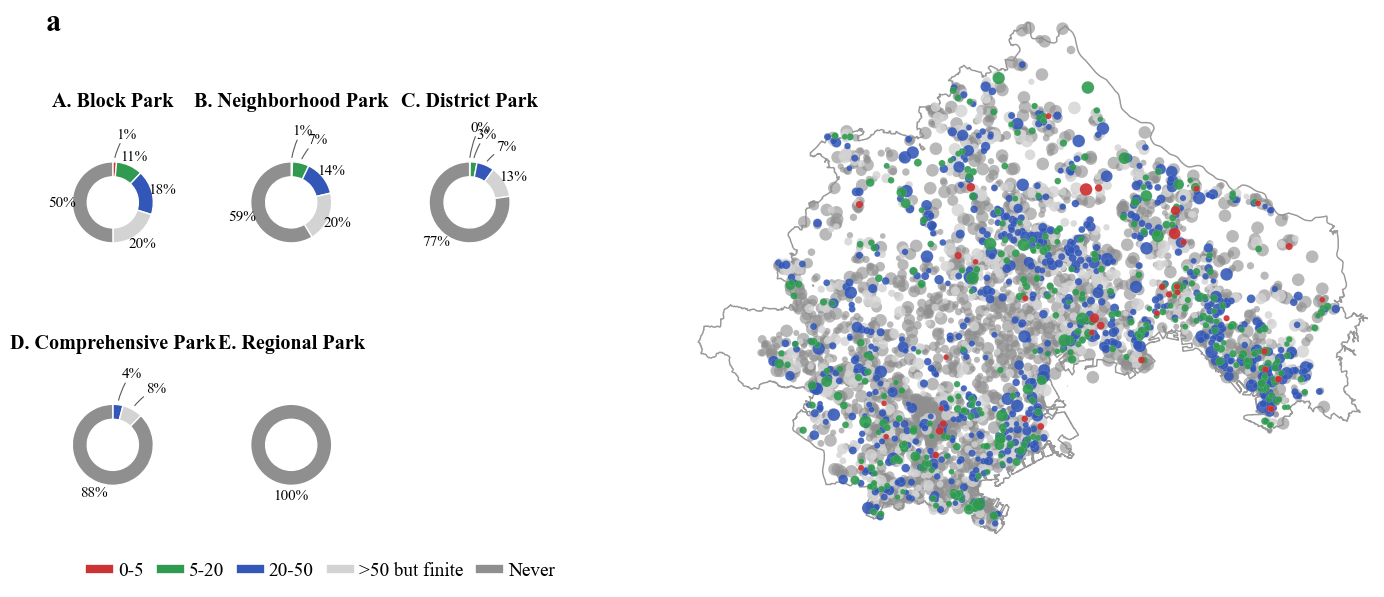

In [57]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# ====== 写死，防止吃到旧变量 ======
PARKS_CSV = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_main2pct.csv"
BASE_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"
MAP_RATE_TAG = "r2"

SAVE_FIG = False
OUT_FIG = "park_map_with_type_donuts_r2_5class_clean_v4.png"

PAYBACK_HORIZON = 50
SIZE_Q = 0.90
SIZE_MIN = 4
SIZE_MAX = 110

FS_PANEL = 22
FS_PIE_PCT = 11
FS_TYPE_TITLE = 14.5
FS_LEGEND = 13.8

# ====== 强制重新读 ======
df = pd.read_csv(PARKS_CSV, encoding="utf-8-sig").copy()
print("Loaded:", PARKS_CSV)
print("Using:", f"discounted_payback_years_{MAP_RATE_TAG}")

PAYBACK_COL = f"discounted_payback_years_{MAP_RATE_TAG}"

for c in ["Lng", "Lat", "area_m2", PAYBACK_COL]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

COLOR_RED = "#cc3333"
COLOR_GREEN = "#2f9a50"
COLOR_BLUE = "#3257b7"
COLOR_LIGHTGRAY = "#d3d3d3"
COLOR_DARKGRAY = "#8f8f8f"
BG_COLOR = "white"

CAT_ORDER = ["0-5", "5-20", "20-50", ">50 finite", "Never"]
CAT_COLORS = [COLOR_RED, COLOR_GREEN, COLOR_BLUE, COLOR_LIGHTGRAY, COLOR_DARKGRAY]

def classify_payback_5(x):
    if pd.isna(x) or np.isinf(x):
        return "Never"
    if x <= 5:
        return "0-5"
    elif x <= 20:
        return "5-20"
    elif x <= 50:
        return "20-50"
    else:
        return ">50 finite"

df["payback_years"] = df[PAYBACK_COL]
df["payback_bin_5"] = df["payback_years"].apply(classify_payback_5)
df["map_group"] = df["payback_years"].apply(classify_payback_5)

print("\nOverall group counts:")
print(df["payback_bin_5"].value_counts(dropna=False))

print("\nBy park type (%):")
check = (
    df.groupby("park_class")["payback_bin_5"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .pivot(index="park_class", columns="payback_bin_5", values="share")
    .fillna(0)
)
print((check * 100).round(1))

df_map = df[np.isfinite(df["Lng"]) & np.isfinite(df["Lat"])].copy()

base = gpd.read_file(BASE_SHP)
base_outline = base.dissolve()

gdf = gpd.GeoDataFrame(
    df_map.copy(),
    geometry=gpd.points_from_xy(df_map["Lng"], df_map["Lat"]),
    crs="EPSG:4326"
)

if base_outline.crs is not None and str(base_outline.crs) != str(gdf.crs):
    gdf = gdf.to_crs(base_outline.crs)

area = pd.to_numeric(gdf["area_m2"], errors="coerce").fillna(0).clip(lower=0)
sqrt_area = np.sqrt(area)

denom = np.nanquantile(sqrt_area.replace(0, np.nan), SIZE_Q)
if not np.isfinite(denom) or denom <= 0:
    denom = np.nanmax(sqrt_area) if np.nanmax(sqrt_area) > 0 else 1.0

sizes = (sqrt_area / denom) * SIZE_MAX
sizes = sizes.clip(lower=SIZE_MIN, upper=SIZE_MAX)
sizes = sizes * 0.75
gdf["pt_size"] = sizes

g_0_5 = gdf[gdf["map_group"] == "0-5"].copy()
g_5_20 = gdf[gdf["map_group"] == "5-20"].copy()
g_20_50 = gdf[gdf["map_group"] == "20-50"].copy()
g_gt50 = gdf[gdf["map_group"] == ">50 finite"].copy()
g_never = gdf[gdf["map_group"] == "Never"].copy()

fig = plt.figure(figsize=(15.0, 6.1), facecolor=BG_COLOR)

gs_outer = fig.add_gridspec(
    nrows=1, ncols=2,
    width_ratios=[2.9, 6.0],
    left=0.02, right=0.992, top=0.965, bottom=0.11,
    wspace=0.035
)

gs_left = gs_outer[0, 0].subgridspec(
    nrows=2, ncols=3,
    hspace=0.78, wspace=0.62
)

ax_positions = [
    fig.add_subplot(gs_left[0, 0]),
    fig.add_subplot(gs_left[0, 1]),
    fig.add_subplot(gs_left[0, 2]),
    fig.add_subplot(gs_left[1, 0]),
    fig.add_subplot(gs_left[1, 1]),
]

for ax in ax_positions[:3]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.15, pos.width, pos.height])

ax_blank = fig.add_subplot(gs_left[1, 2])
ax_blank.axis("off")
ax_map = fig.add_subplot(gs_outer[0, 1])

for ax in ax_positions + [ax_map]:
    ax.set_facecolor(BG_COLOR)

def annotate_donut(ax, wedges, values, total):
    if total <= 0:
        return

    labels_info = []
    for w, v in zip(wedges, values):
        if v <= 0:
            continue
        pct = 100.0 * v / total
        label = f"{pct:.0f}%"
        ang = 0.5 * (w.theta1 + w.theta2)
        ang_rad = np.deg2rad(ang)
        x = np.cos(ang_rad)
        y = np.sin(ang_rad)
        labels_info.append({"pct": pct, "label": label, "x": x, "y": y})

    small_upper = [d for d in labels_info if d["pct"] < 10 and d["y"] > 0]
    small_upper = sorted(small_upper, key=lambda z: z["y"])

    for i, d in enumerate(small_upper):
        d["y_shift"] = (i - (len(small_upper) - 1) / 2.0) * 0.10

    for d in labels_info:
        d.setdefault("y_shift", 0.0)
        x, y, pct, label = d["x"], d["y"], d["pct"], d["label"]

        if pct < 10:
            r_line = 1.02
            r_text = 1.56
            ha = "left" if x >= 0 else "right"
            ax.annotate(
                label,
                xy=(r_line * x, r_line * y),
                xytext=(r_text * x, r_text * (y + d["y_shift"])),
                ha=ha, va="center", fontsize=FS_PIE_PCT,
                arrowprops=dict(
                    arrowstyle="-", color="0.35", lw=0.8,
                    shrinkA=0, shrinkB=0,
                    connectionstyle="arc3,rad=0.10"
                )
            )
        else:
            r_text = 1.15
            ax.text(r_text * x, r_text * y, label,
                    ha="center", va="center", fontsize=FS_PIE_PCT)

type_order = ["A", "B", "C", "D", "E"]
type_name_map = {
    "A": "Block Park",
    "B": "Neighborhood Park",
    "C": "District Park",
    "D": "Comprehensive Park",
    "E": "Regional Park"
}

for ax_pie, t in zip(ax_positions, type_order):
    sub = df[df["park_class"].astype(str) == t].copy()
    counts = sub["payback_bin_5"].value_counts().reindex(CAT_ORDER, fill_value=0)
    total = int(counts.sum())
    sizes_pie = counts.values if total > 0 else [0, 0, 0, 0, 1]

    wedges, _ = ax_pie.pie(
        sizes_pie,
        colors=CAT_COLORS,
        startangle=90,
        counterclock=False,
        radius=0.92,
        wedgeprops=dict(width=0.34, edgecolor=BG_COLOR)
    )
    annotate_donut(ax_pie, wedges, sizes_pie, total)

    ax_pie.set_aspect("equal")
    ax_pie.set_xticks([])
    ax_pie.set_yticks([])
    ax_pie.set_title(
        f"{t}. {type_name_map[t]}",
        fontsize=FS_TYPE_TITLE,
        fontweight="bold",
        pad=30
    )

fig.text(0.012, 0.978, "a", fontsize=FS_PANEL, fontweight="bold", ha="left", va="top")

base_outline.boundary.plot(ax=ax_map, linewidth=1.05, color="0.6", zorder=1)

if len(g_never) > 0:
    ax_map.scatter(g_never.geometry.x, g_never.geometry.y,
                   s=g_never["pt_size"].values, color=COLOR_DARKGRAY,
                   alpha=0.62, linewidths=0, zorder=2)

if len(g_gt50) > 0:
    ax_map.scatter(g_gt50.geometry.x, g_gt50.geometry.y,
                   s=g_gt50["pt_size"].values, color=COLOR_LIGHTGRAY,
                   alpha=0.82, linewidths=0, zorder=2.15)

if len(g_20_50) > 0:
    ax_map.scatter(g_20_50.geometry.x, g_20_50.geometry.y,
                   s=g_20_50["pt_size"].values, color=COLOR_BLUE,
                   alpha=0.88, linewidths=0.08, edgecolors="white", zorder=3)

if len(g_5_20) > 0:
    ax_map.scatter(g_5_20.geometry.x, g_5_20.geometry.y,
                   s=g_5_20["pt_size"].values, color=COLOR_GREEN,
                   alpha=0.90, linewidths=0.08, edgecolors="white", zorder=3.2)

if len(g_0_5) > 0:
    ax_map.scatter(g_0_5.geometry.x, g_0_5.geometry.y,
                   s=g_0_5["pt_size"].values, color=COLOR_RED,
                   alpha=0.93, linewidths=0.08, edgecolors="white", zorder=3.4)

ax_map.set_axis_off()

xmin, ymin, xmax, ymax = base_outline.total_bounds
xpad = (xmax - xmin) * 0.01
ypad = (ymax - ymin) * 0.01
ax_map.set_xlim(xmin - xpad, xmax + xpad)
ax_map.set_ylim(ymin - ypad, ymax + ypad)

handles_left = [
    Line2D([0], [0], color=COLOR_RED, lw=6, label="0-5"),
    Line2D([0], [0], color=COLOR_GREEN, lw=6, label="5-20"),
    Line2D([0], [0], color=COLOR_BLUE, lw=6, label="20-50"),
    Line2D([0], [0], color=COLOR_LIGHTGRAY, lw=6, label=">50 but finite"),
    Line2D([0], [0], color=COLOR_DARKGRAY, lw=6, label="Never"),
]

fig.legend(
    handles=handles_left,
    loc="lower left",
    bbox_to_anchor=(0.03, 0.015),
    ncol=5,
    frameon=False,
    fontsize=FS_LEGEND,
    handlelength=1.0,
    columnspacing=0.9,
    handletextpad=0.45
)

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=300, bbox_inches="tight", facecolor="white")
    print("Saved:", OUT_FIG)

plt.show()

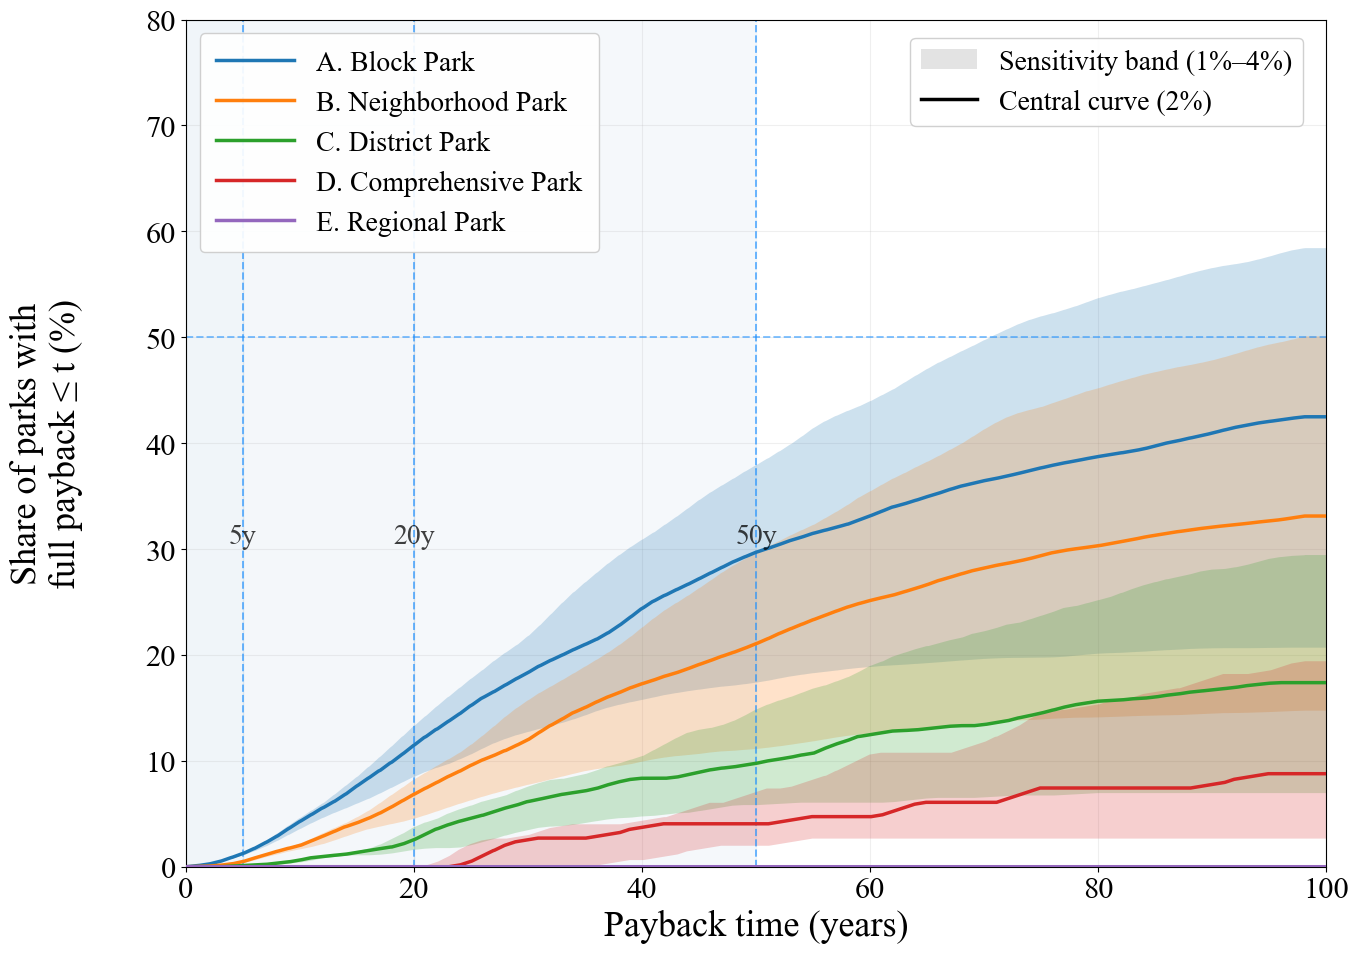

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# 0) 数据源与列名
# =========================
if "df" in globals():
    SOURCE_DF = df.copy()
else:
    SOURCE_DF = pd.read_csv(
        r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y.csv",
        encoding="utf-8-sig"
    )

TYPE_NAME_COL = "park_class_name"
TYPE_CODE_COL = "park_class"

# 主图：1%–4% 敏感性带 + 2% 中线
PAY_COLS = {
    "1%": "discounted_payback_years_r1",
    "2%": "discounted_payback_years_r2",
    "4%": "discounted_payback_years_r4",
}

# =========================
# 1) 参数
# =========================
T1, T2, T3 = 5, 20, 50
X_MAX = 100
Y_MAX = 80
ECDF_GRID_N = 1600
SMOOTH_WIN = 61

TEXT_SCALE = 1.85

SAVE_FIG = False
OUT_FIG = "park_payback_sensitivity_ribbon_fullpayback_x100.png"

# =========================
# 2) 字体与样式
# =========================
plt.rcdefaults()
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

FONT_MAIN   = int(round(12 * TEXT_SCALE))
FONT_LABEL  = int(round(14 * TEXT_SCALE))
FONT_TICK   = int(round(12 * TEXT_SCALE))
FONT_LEGEND = int(round(11 * TEXT_SCALE))
FONT_ANNO   = int(round(11 * TEXT_SCALE))

plt.rcParams.update({
    "font.size": FONT_MAIN,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
})

# =========================
# 3) 公园类型映射
# =========================
type_names = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

KEYWORD_RULES = [
    ("block", "A"),
    ("neighborhood", "B"),
    ("neighbourhood", "B"),
    ("district", "C"),
    ("comprehensive", "D"),
    ("regional", "E"),
]

def map_name_to_abc(name: str):
    if name is None:
        return None
    s = str(name).strip()
    if s == "" or s.lower() == "nan":
        return None
    sl = s.lower()
    for kw, code in KEYWORD_RULES:
        if kw in sl:
            return code
    return None

d = SOURCE_DF.copy()

if TYPE_CODE_COL in d.columns:
    d["abcde"] = d[TYPE_CODE_COL].astype(str).str.strip()
else:
    d["abcde"] = d[TYPE_NAME_COL].apply(map_name_to_abc)

d = d[d["abcde"].isin(list("ABCDE"))].copy()
if len(d) == 0:
    raise ValueError("过滤 A–E 后为空，请检查 park_class / park_class_name。")

for _, c in PAY_COLS.items():
    if c not in d.columns:
        raise KeyError(f"缺少列：{c}")
    d[c] = pd.to_numeric(d[c], errors="coerce")

# =========================
# 4) 正确的累计占比函数（基于完整回本年限）
#    分母 = 全部该类型公园
#    finite payback <= t 进入分子
#    inf(never) 保留在分母，不进分子
# =========================
def cumulative_share_all_parks_full(payback_series, x_grid):
    s = pd.to_numeric(payback_series, errors="coerce")
    n_total = len(s)

    if n_total == 0:
        return np.full_like(x_grid, np.nan, dtype=float)

    valid = s[np.isfinite(s) & (s >= 0)].values.astype(float)
    if valid.size == 0:
        return np.zeros_like(x_grid, dtype=float)

    valid = np.sort(valid)
    counts = np.searchsorted(valid, x_grid, side="right")
    y = counts / n_total * 100.0
    return y

def smooth_monotone(y, win=61):
    y = np.asarray(y, float)
    m = np.isfinite(y)
    if m.sum() < 5:
        return y

    yy = y.copy()
    yy[~m] = np.interp(np.flatnonzero(~m), np.flatnonzero(m), yy[m])

    win = int(win)
    if win < 3:
        return np.maximum.accumulate(np.clip(yy, 0, 100))
    if win % 2 == 0:
        win += 1

    kernel = np.ones(win, dtype=float) / win
    ys = np.convolve(yy, kernel, mode="same")
    ys = np.clip(ys, 0, 100)
    ys = np.maximum.accumulate(ys)
    return ys

# =========================
# 5) 颜色
# =========================
type_colors = {
    "A": "#1f77b4",
    "B": "#ff7f0e",
    "C": "#2ca02c",
    "D": "#d62728",
    "E": "#9467bd",
}

# =========================
# 6) 画图
# =========================
fig, ax = plt.subplots(figsize=(14, 10))

x_grid = np.linspace(0, X_MAX, ECDF_GRID_N)

# 背景分区
ax.axvspan(0,  T1, alpha=0.08, color="steelblue")
ax.axvspan(T1, T2, alpha=0.06, color="steelblue")
ax.axvspan(T2, T3, alpha=0.05, color="steelblue")

legend_handles = []
legend_labels = []

for g in ["A", "B", "C", "D", "E"]:
    sub = d[d["abcde"] == g].copy()
    if len(sub) == 0:
        continue

    curves = []
    for rate_label, col in PAY_COLS.items():
        y = cumulative_share_all_parks_full(sub[col], x_grid)
        y = smooth_monotone(y, win=SMOOTH_WIN)
        curves.append(y)

    Y = np.vstack(curves)

    y_low = np.nanmin(Y, axis=0)
    y_high = np.nanmax(Y, axis=0)
    y_mid = curves[list(PAY_COLS.keys()).index("2%")]

    ax.fill_between(
        x_grid, y_low, y_high,
        color=type_colors[g],
        alpha=0.22,
        linewidth=0,
        zorder=2
    )

    line, = ax.plot(
        x_grid, y_mid,
        color=type_colors[g],
        linewidth=2.5,
        zorder=3
    )

    legend_handles.append(line)
    legend_labels.append(type_names[g])

# 参考线
ax.axhline(50, ls="--", lw=1.4, alpha=0.55, color="dodgerblue")
for t, lab in [(T1, "5y"), (T2, "20y"), (T3, "50y")]:
    ax.axvline(t, ls="--", lw=1.4, alpha=0.65, color="dodgerblue")
    ax.text(
        t, 30,
        lab,
        ha="center", va="bottom",
        alpha=0.75,
        fontsize=FONT_ANNO
    )

# 轴
ax.set_xlabel("Payback time (years)")
ax.set_ylabel("Share of parks with\nfull payback ≤ t (%)", labelpad=18)
ax.yaxis.set_label_coords(-0.09, 0.5)

ax.set_xlim(0, X_MAX)
ax.set_ylim(0, Y_MAX)
ax.grid(True, alpha=0.20)

# 图例1：类型
leg1 = ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="upper left",
    ncol=1,
    frameon=True,
    framealpha=0.92,
    borderpad=0.6,
    handlelength=2.8
)

# 图例2：色带含义
band_patch = Patch(facecolor="gray", alpha=0.22, edgecolor="none", label="Sensitivity band (1%–4%)")
mid_line = plt.Line2D([0], [0], color="black", lw=2.5, label="Central curve (2%)")

leg2 = ax.legend(
    handles=[band_patch, mid_line],
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.92
)
ax.add_artist(leg1)

plt.tight_layout()

if SAVE_FIG:
    plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")

plt.show()

Loaded CSV: ...main2pct.csv
MAIN_RATE: 0.02
Rows used: 4822
Capital recovery factor: 0.03182320970369655
5%-95% range: [-19126.17, 14637.11]
N shown: 4,338
N excluded: 484
Mean: -2983.30
Median: -2901.78
Histogram x-range: [-20000, 16000]
Bin width = 2000, number of bins = 18


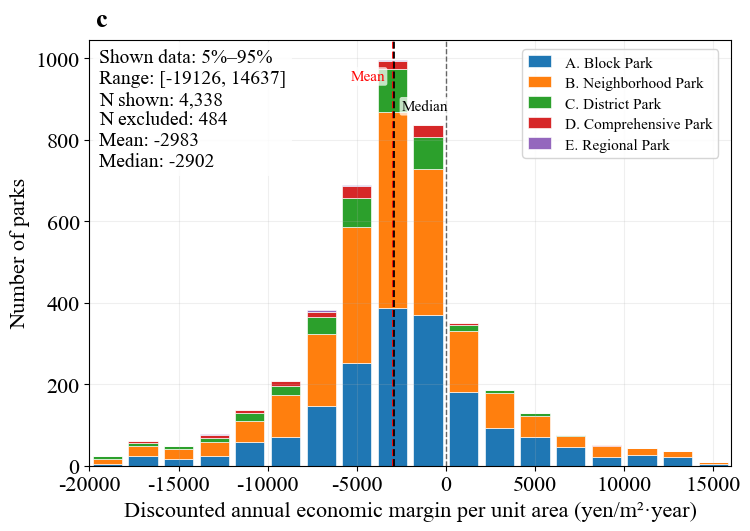

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# 0) CONFIG
# =======================
# 强制读取 2% 主口径的新表，不沿用旧 df
SOURCE_DF = pd.read_csv(
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_discounted_multi_rate_fullpayback_2019_50y_main2pct.csv",
    encoding="utf-8-sig"
).copy()

BIN_W = 2000.0
TEXT_SCALE = 1.55

# 与最新主分析一致：2%
MAIN_RATE = 0.02
EVAL_YEARS = 50

SAVE_FIG = False
OUT_FIG = "economic_margin_per_m2_hist_stacked_abcde_fullpayback_main2pct.png"

TYPE_NAME = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

print("Loaded CSV: ...main2pct.csv")
print("MAIN_RATE:", MAIN_RATE)

# =======================
# 1) FONT / STYLE
# =======================
plt.rcdefaults()
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

BASE_FONT   = int(round(10 * TEXT_SCALE))
LABEL_FONT  = int(round(10 * TEXT_SCALE))
TICK_FONT   = int(round(10 * TEXT_SCALE))
LEGEND_FONT = int(round(8.0 * TEXT_SCALE))
NOTE_FONT   = int(round(9.2 * TEXT_SCALE))
PANEL_FONT  = int(round(12 * TEXT_SCALE))
LINE_NOTE_FONT = int(round(7.2 * TEXT_SCALE))

plt.rcParams.update({
    "font.size": BASE_FONT,
    "axes.labelsize": LABEL_FONT,
    "xtick.labelsize": TICK_FONT,
    "ytick.labelsize": TICK_FONT,
    "legend.fontsize": LEGEND_FONT,
})

# =======================
# 2) CHECK REQUIRED COLUMNS
# =======================
need_cols = [
    "park_class",
    "area_m2",
    "annual_net_benefit_2019",
    "one_time_investment_2019",
]
miss = [c for c in need_cols if c not in SOURCE_DF.columns]
if miss:
    raise KeyError(f"df 缺少列：{miss}。请先运行前面的新版计算代码。")

d = SOURCE_DF.copy()

d["park_class"] = d["park_class"].astype(str).str.strip()
d["area_m2"] = pd.to_numeric(d["area_m2"], errors="coerce")
d["annual_net_benefit_2019"] = pd.to_numeric(d["annual_net_benefit_2019"], errors="coerce")
d["one_time_investment_2019"] = pd.to_numeric(d["one_time_investment_2019"], errors="coerce")

d = d[d["park_class"].isin(list("ABCDE"))].copy()
d = d[np.isfinite(d["area_m2"]) & (d["area_m2"] > 0)].copy()
d = d[np.isfinite(d["annual_net_benefit_2019"])].copy()
d = d[np.isfinite(d["one_time_investment_2019"])].copy()

if len(d) == 0:
    raise ValueError("没有可用于绘图的有效记录。")

print("Rows used:", len(d))

# =======================
# 3) DISCOUNTED ANNUALIZED CAPITAL CHARGE
# =======================
# CRF = r / (1 - (1+r)^(-T))
if MAIN_RATE <= 0:
    raise ValueError("这张图的 annualized capital charge 需要 MAIN_RATE > 0。")

crf = MAIN_RATE / (1 - (1 + MAIN_RATE) ** (-EVAL_YEARS))
print("Capital recovery factor:", crf)

d["annualized_capital_charge_2019"] = d["one_time_investment_2019"] * crf

# 与当前主分析一致的经济盈余/亏损指标（2%）
d["economic_margin_yen_per_m2"] = (
    d["annual_net_benefit_2019"] - d["annualized_capital_charge_2019"]
) / d["area_m2"]

x_all = pd.to_numeric(d["economic_margin_yen_per_m2"], errors="coerce")
x_all = x_all[np.isfinite(x_all)]

if x_all.size == 0:
    raise ValueError("economic_margin_yen_per_m2 没有有效值。")

# =======================
# 4) 5%–95% RANGE
# =======================
q05, q95 = np.percentile(x_all.values.astype(float), [5, 95])

inrange = (d["economic_margin_yen_per_m2"] >= q05) & (d["economic_margin_yen_per_m2"] <= q95)
d_in = d[inrange].copy()
excluded = len(d) - len(d_in)

x = d_in["economic_margin_yen_per_m2"].values.astype(float)
mean_x = float(np.mean(x))
median_x = float(np.median(x))

print(f"5%-95% range: [{q05:.2f}, {q95:.2f}]")
print(f"N shown: {len(d_in):,}")
print(f"N excluded: {excluded:,}")
print(f"Mean: {mean_x:.2f}")
print(f"Median: {median_x:.2f}")

# =======================
# 5) FIXED-WIDTH BINS + X RANGE
# =======================
left_data = np.floor(x.min() / BIN_W) * BIN_W
right_data = np.ceil(x.max() / BIN_W) * BIN_W

left = min(left_data, -10000)
right = max(right_data, 15000)

bins = np.arange(left, right + BIN_W, BIN_W)

groups = ["A", "B", "C", "D", "E"]
data_by_g = [
    d_in.loc[d_in["park_class"] == g, "economic_margin_yen_per_m2"].values.astype(float)
    for g in groups
]
legend_labels = [TYPE_NAME[g] for g in groups]

print(f"Histogram x-range: [{left:.0f}, {right:.0f}]")
print(f"Bin width = {BIN_W:.0f}, number of bins = {len(bins)-1}")

# =======================
# 6) PLOT
# =======================
fig, ax = plt.subplots(figsize=(7.8, 5.6))

ax.hist(
    data_by_g,
    bins=bins,
    stacked=True,
    rwidth=0.82,
    edgecolor="white",
    linewidth=0.45,
    label=legend_labels,
)

# 0 线
ax.axvline(0, linestyle="--", linewidth=1.0, color="0.4")

# Mean / Median 线
ax.axvline(mean_x, linestyle="--", linewidth=1.35, color="red", alpha=0.95)
ax.axvline(median_x, linestyle="--", linewidth=1.35, color="black", alpha=0.95)

ax.grid(True, alpha=0.20)

ax.set_xlabel("Discounted annual economic margin per unit area (yen/m²·year)")
ax.set_ylabel("Number of parks")

# panel label
ax.text(
    0.01, 1.02, "c",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=PANEL_FONT, fontweight="bold"
)

# 左上角说明
note = (
    f"Shown data: 5%–95%\n"
    f"Range: [{q05:.0f}, {q95:.0f}]\n"
    f"N shown: {len(d_in):,}\n"
    f"N excluded: {excluded:,}\n"
    f"Mean: {mean_x:.0f}\n"
    f"Median: {median_x:.0f}"
)
ax.text(
    0.015, 0.98, note,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=NOTE_FONT,
    bbox=dict(facecolor="white", alpha=0.82, edgecolor="none", boxstyle="round,pad=0.30")
)

# 右上角图例
leg = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.82,
    handlelength=1.4,
    labelspacing=0.35,
    borderpad=0.35,
)
for t in leg.get_texts():
    t.set_fontsize(t.get_fontsize() * 0.92)

# x 轴范围和刻度保持原来逻辑
ax.set_xlim(left, right)

tick_start = int(np.ceil(left / 5000.0) * 5000)
tick_end = int(np.floor(right / 5000.0) * 5000)
xticks = np.arange(tick_start, tick_end + 1, 5000)
if len(xticks) > 0:
    ax.set_xticks(xticks)

# =======================
# 7) Mean / Median 标签
# =======================
y_top = ax.get_ylim()[1]
x_span = right - left
x_offset = x_span * 0.012

close_lines = abs(mean_x - median_x) < x_span * 0.04
y_mean = y_top * (0.93 if close_lines else 0.95)
y_median = y_top * (0.86 if close_lines else 0.95)

ax.text(
    mean_x - x_offset,
    y_mean,
    "Mean",
    ha="right",
    va="top",
    fontsize=LINE_NOTE_FONT,
    color="red",
    bbox=dict(facecolor="white", alpha=0.72, edgecolor="none", boxstyle="round,pad=0.15")
)

ax.text(
    median_x + x_offset,
    y_median,
    "Median",
    ha="left",
    va="top",
    fontsize=LINE_NOTE_FONT,
    color="black",
    bbox=dict(facecolor="white", alpha=0.72, edgecolor="none", boxstyle="round,pad=0.15")
)

plt.tight_layout()

if SAVE_FIG:
    plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
    print("Saved ->", OUT_FIG)

plt.show()

In [12]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import pandas as pd

t0 = time.perf_counter()

# =========================================================
# 0) PATHS / SETTINGS
# =========================================================
VISIT_FILES = [
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv",
]

COST_XLSX = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/"
    r"成本计算/13_park_medical_and_landprice_with_geo_type_maintenance_2024.xlsx"
)

OUT_DIR = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
)
os.makedirs(OUT_DIR, exist_ok=True)

# 输出文件
OUT_TABLE_CSV = os.path.join(
    OUT_DIR,
    "park_payback_growth_discounted_2019_50y_r2_b1_om1.csv"
)
OUT_TYPE_SUMMARY_CSV = os.path.join(
    OUT_DIR,
    "park_payback_growth_discounted_2019_50y_by_type_r2_b1_om1.csv"
)
OUT_DIAG_TXT = os.path.join(
    OUT_DIR,
    "park_payback_growth_discounted_2019_50y_diagnostics_r2_b1_om1.txt"
)

# =========================================================
# 1) CORE ECONOMIC SETTINGS
# =========================================================
BASE_YEAR = 2019
EVAL_YEARS = 50
DISCOUNT_RATE = 0.02          # 2% 折现率

# ===== 你主要改这里 =====
BENEFIT_GROWTH = 0.02        # 收益每年增长 1%
OM_GROWTH = 0.02              # 维护费每年增长 1%

# 收益参数
YEN_PER_STEP_2019 = 0.04056
EXPANSION_FACTOR = 150

# 成本参数
CONSTRUCTION_UNIT_COST_2014 = 12000.0
AREA_IS_HECTARE_WHEN_ONLY_AREA = False

# =========================================================
# 2) CPI TO CONSTANT 2019 JPY
# =========================================================
# 把不同年份的成本统一折算到 2019 不变价
CPI_2003_2015BASE = 97.2
CPI_2014_2015BASE = 102.8 / 103.6 * 100.0
CPI_2019_2015BASE = 101.8

CONSTRUCTION_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2014_2015BASE
OM_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2003_2015BASE

# =========================================================
# 3) HELPERS
# =========================================================
def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s

def first_valid(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def numeric_median(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.median()) if len(s) else np.nan

def pick_column(columns, exact_candidates=(), contains_all=(), contains_any=(),
                required=True, label="column"):
    cols = list(columns)
    lower_map = {c.lower(): c for c in cols}

    for cand in exact_candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    for c in cols:
        cl = c.lower()
        ok_all = all(k.lower() in cl for k in contains_all) if contains_all else True
        ok_any = any(k.lower() in cl for k in contains_any) if contains_any else True
        if ok_all and ok_any:
            return c

    if required:
        raise KeyError(f"Cannot find {label}. Available columns:\n{cols}")
    return None

def classify_payback_year(y):
    if pd.isna(y):
        return "invalid"
    if np.isinf(y):
        return "never"
    if y <= 5:
        return "0-5"
    elif y <= 20:
        return "5-20"
    elif y <= 50:
        return "20-50"
    else:
        return ">50"

def discounted_payback_with_growth(invest, annual_benefit_0, annual_om_0,
                                   r, g_b, g_om, years=50):
    """
    逐年模拟版：
    - 一次性投资 invest 在 t=0 支出
    - 第 t 年收益 = annual_benefit_0 * (1+g_b)^(t-1)
    - 第 t 年维护费 = annual_om_0 * (1+g_om)^(t-1)
    - 每年净收益折现到 2019
    返回：
    - full_payback_year: 若 50 年内未回本但未来可能回本，也先返回 >50 的实际年数（最多算到 500 年）
    - payback_50y: 若 50 年内回本则给具体年数，否则 NaN
    - npv_50y
    - status_50y
    """
    if not np.isfinite(invest) or not np.isfinite(annual_benefit_0) or not np.isfinite(annual_om_0):
        return np.nan, np.nan, np.nan, "invalid"

    if invest <= 0:
        npv_50y = 0.0
        for t in range(1, years + 1):
            benefit_t = annual_benefit_0 * ((1 + g_b) ** (t - 1))
            om_t = annual_om_0 * ((1 + g_om) ** (t - 1))
            net_t = benefit_t - om_t
            npv_50y += net_t / ((1 + r) ** t)
        return 0.0, 0.0, npv_50y, "recouped within 50 years"

    cum_pv = 0.0
    payback_year = np.nan
    npv_50y = -invest

    # 先算 50 年内
    for t in range(1, years + 1):
        benefit_t = annual_benefit_0 * ((1 + g_b) ** (t - 1))
        om_t = annual_om_0 * ((1 + g_om) ** (t - 1))
        net_t = benefit_t - om_t
        pv_t = net_t / ((1 + r) ** t)

        cum_pv += pv_t
        npv_50y += pv_t

        if pd.isna(payback_year) and cum_pv >= invest:
            payback_year = float(t)

    if pd.notna(payback_year):
        return payback_year, payback_year, npv_50y, "recouped within 50 years"

    # 若 50 年内未回本，继续往后算，最多到 500 年，看是 >50 还是 never
    cum_pv_long = cum_pv
    max_year_long = 500
    payback_year_long = np.nan

    for t in range(years + 1, max_year_long + 1):
        benefit_t = annual_benefit_0 * ((1 + g_b) ** (t - 1))
        om_t = annual_om_0 * ((1 + g_om) ** (t - 1))
        net_t = benefit_t - om_t
        pv_t = net_t / ((1 + r) ** t)

        cum_pv_long += pv_t

        if pd.isna(payback_year_long) and cum_pv_long >= invest:
            payback_year_long = float(t)
            break

    if pd.notna(payback_year_long):
        return payback_year_long, np.nan, npv_50y, "not recouped within 50 years"
    else:
        return np.inf, np.nan, npv_50y, "never pay back"

# =========================================================
# 4) READ VISIT DATA
# =========================================================
visit_frames = []
for fp in VISIT_FILES:
    df0 = pd.read_csv(fp, low_memory=False)
    visit_frames.append(df0)

visits = pd.concat(visit_frames, ignore_index=True)

# 自动找列
osm_col = pick_column(
    visits.columns,
    exact_candidates=("osm_id",),
    contains_any=("osm_id",),
    label="osm_id"
)
steps_col = pick_column(
    visits.columns,
    exact_candidates=("steps",),
    contains_any=("steps",),
    label="steps"
)
lat_col = pick_column(
    visits.columns,
    exact_candidates=("Lat", "lat", "latitude"),
    contains_any=("lat",),
    label="lat"
)
lng_col = pick_column(
    visits.columns,
    exact_candidates=("Lng", "lng", "lon", "longitude"),
    contains_any=("lng", "lon"),
    label="lng"
)
area_col = pick_column(
    visits.columns,
    exact_candidates=("area_m2", "area"),
    contains_any=("area",),
    label="area"
)
park_class_col = pick_column(
    visits.columns,
    exact_candidates=("park_class",),
    contains_all=("park", "class"),
    contains_any=("class",),
    required=False,
    label="park_class"
)
park_class_name_col = pick_column(
    visits.columns,
    exact_candidates=("park_class_name",),
    contains_all=("park", "class", "name"),
    contains_any=("class_name", "park_class_name"),
    required=False,
    label="park_class_name"
)

visits = visits.copy()
visits["osm_id_norm"] = norm_osm(visits[osm_col])
visits["steps_num"] = pd.to_numeric(visits[steps_col], errors="coerce")
visits["lat_num"] = pd.to_numeric(visits[lat_col], errors="coerce")
visits["lng_num"] = pd.to_numeric(visits[lng_col], errors="coerce")
visits["area_raw"] = pd.to_numeric(visits[area_col], errors="coerce")

if AREA_IS_HECTARE_WHEN_ONLY_AREA:
    visits["area_m2"] = visits["area_raw"] * 10000.0
else:
    visits["area_m2"] = visits["area_raw"]

group_cols = ["osm_id_norm"]

agg_dict = {
    "lat_num": "mean",
    "lng_num": "mean",
    "area_m2": numeric_median,
    "steps_num": "sum",
}

if park_class_col is not None:
    agg_dict[park_class_col] = first_valid
if park_class_name_col is not None:
    agg_dict[park_class_name_col] = first_valid

park_agg = (
    visits.loc[visits["osm_id_norm"].notna()]
    .groupby(group_cols, dropna=False, as_index=False)
    .agg(agg_dict)
)

park_agg = park_agg.rename(columns={
    "lat_num": "Lat",
    "lng_num": "Lng",
    "steps_num": "steps_sum",
})
if park_class_col is not None and park_class_col in park_agg.columns:
    park_agg = park_agg.rename(columns={park_class_col: "park_class"})
if park_class_name_col is not None and park_class_name_col in park_agg.columns:
    park_agg = park_agg.rename(columns={park_class_name_col: "park_class_name"})

# 如果 park_class 缺失，但 park_class_name 存在，可尝试从名字映射
if "park_class" not in park_agg.columns and "park_class_name" in park_agg.columns:
    name_map = {
        "City block park": "A",
        "Neighborhood Park": "B",
        "District Park": "C",
        "Comprehensive Park": "D",
        "Regional Park": "E",
    }
    park_agg["park_class"] = park_agg["park_class_name"].map(name_map)

# 年收益（2019 不变价）
park_agg["annual_benefit_yen_2019"] = (
    park_agg["steps_sum"].fillna(0.0) * YEN_PER_STEP_2019 * EXPANSION_FACTOR
)

# =========================================================
# 5) READ COST DATA
# =========================================================
cost = pd.read_excel(COST_XLSX)

cost_osm_col = pick_column(
    cost.columns,
    exact_candidates=("osm_id",),
    contains_any=("osm_id",),
    label="cost osm_id"
)
cost["osm_id_norm"] = norm_osm(cost[cost_osm_col])

# 地价列
land_price_col = pick_column(
    cost.columns,
    exact_candidates=("price_fina", "land_price", "price", "unit_land_price"),
    contains_any=("price_fina", "land_price", "price"),
    label="land price"
)

# 维护费列
om_unit_col = pick_column(
    cost.columns,
    exact_candidates=("unit_maintenance_yen_per_m2_2024", "maint", "maintenance", "unit_maintenance"),
    contains_any=("maint", "maintenance"),
    label="maintenance unit cost"
)

cost["land_price_num"] = pd.to_numeric(cost[land_price_col], errors="coerce")
cost["om_unit_raw"] = pd.to_numeric(cost[om_unit_col], errors="coerce")

cost_use = cost[["osm_id_norm", "land_price_num", "om_unit_raw"]].copy()

# =========================================================
# 6) MERGE
# =========================================================
df = park_agg.merge(cost_use, on="osm_id_norm", how="left")

# 维护费统一折算到 2019
df["maint_2019"] = df["om_unit_raw"] * OM_TO_2019_FACTOR

# 建造成本统一折算到 2019
df["construction_unit_cost_2019"] = CONSTRUCTION_UNIT_COST_2014 * CONSTRUCTION_TO_2019_FACTOR

# 面积
df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")

# 一次性投资
df["land_cost_2019"] = df["land_price_num"] * df["area_m2"]
df["construction_cost_2019"] = df["construction_unit_cost_2019"] * df["area_m2"]
df["one_time_investment_2019"] = df["land_cost_2019"] + df["construction_cost_2019"]

# 年维护费（2019 基年）
df["annual_om_cost_2019"] = df["maint_2019"] * df["area_m2"]

# 2019 基年净收益（仅作参考）
df["annual_net_benefit_2019"] = df["annual_benefit_yen_2019"] - df["annual_om_cost_2019"]

# =========================================================
# 7) PAYBACK WITH GROWTH + DISCOUNT
# =========================================================
results = df.apply(
    lambda row: discounted_payback_with_growth(
        invest=row["one_time_investment_2019"],
        annual_benefit_0=row["annual_benefit_yen_2019"],
        annual_om_0=row["annual_om_cost_2019"],
        r=DISCOUNT_RATE,
        g_b=BENEFIT_GROWTH,
        g_om=OM_GROWTH,
        years=EVAL_YEARS
    ),
    axis=1,
    result_type="expand"
)

results.columns = [
    "discounted_payback_years_full_growth",
    "discounted_payback_years_50y_growth",
    "npv_50y_growth",
    "discounted_payback_status_50y_growth"
]

df = pd.concat([df, results], axis=1)

df["payback_group_growth"] = df["discounted_payback_years_full_growth"].apply(classify_payback_year)

# =========================================================
# 8) TYPE SUMMARY
# =========================================================
if "park_class" not in df.columns:
    raise KeyError("当前结果里没有 park_class 列，没法按 A-E 五类汇总。请检查 visit 文件中的 park_class / park_class_name 列。")

type_summary = (
    df.groupby("park_class", dropna=False)
      .agg(
          parks_n=("osm_id_norm", "count"),
          annual_benefit_sum_2019=("annual_benefit_yen_2019", "sum"),
          annual_om_sum_2019=("annual_om_cost_2019", "sum"),
          investment_sum_2019=("one_time_investment_2019", "sum"),
          npv_50y_sum_growth=("npv_50y_growth", "sum"),
      )
      .reset_index()
)

group_dist = (
    df.groupby(["park_class", "payback_group_growth"], dropna=False)
      .size()
      .reset_index(name="n")
)

group_dist["pct"] = group_dist.groupby("park_class")["n"].transform(lambda s: s / s.sum() * 100)

# 拉宽成你更容易看的表
type_dist_wide = (
    group_dist.pivot(index="park_class", columns="payback_group_growth", values="pct")
             .fillna(0.0)
             .reset_index()
)

# 确保列顺序固定
for c in ["0-5", "5-20", "20-50", ">50", "never", "invalid"]:
    if c not in type_dist_wide.columns:
        type_dist_wide[c] = 0.0

type_dist_wide = type_dist_wide[
    ["park_class", "0-5", "5-20", "20-50", ">50", "never", "invalid"]
].copy()

type_summary = type_summary.merge(type_dist_wide, on="park_class", how="left")

# 如果有 park_class_name，就补上名字
if "park_class_name" in df.columns:
    class_name_map = (
        df.groupby("park_class", dropna=False)["park_class_name"]
          .agg(first_valid)
          .reset_index()
    )
    type_summary = class_name_map.merge(type_summary, on="park_class", how="right")

# =========================================================
# 9) SAVE
# =========================================================
df.to_csv(OUT_TABLE_CSV, index=False, encoding="utf-8-sig")
type_summary.to_csv(OUT_TYPE_SUMMARY_CSV, index=False, encoding="utf-8-sig")

# =========================================================
# 10) PRINT KEY RESULTS
# =========================================================
print("\n================ 基本参数 ================")
print(f"BASE_YEAR         = {BASE_YEAR}")
print(f"EVAL_YEARS        = {EVAL_YEARS}")
print(f"DISCOUNT_RATE     = {DISCOUNT_RATE:.2%}")
print(f"BENEFIT_GROWTH    = {BENEFIT_GROWTH:.2%}")
print(f"OM_GROWTH         = {OM_GROWTH:.2%}")
print(f"EXPANSION_FACTOR  = {EXPANSION_FACTOR}")
print(f"YEN_PER_STEP_2019 = {YEN_PER_STEP_2019}")

print("\n================ 总体结果 ================")
overall_dist = df["payback_group_growth"].value_counts(dropna=False)
overall_pct = df["payback_group_growth"].value_counts(normalize=True, dropna=False) * 100
overall_show = pd.DataFrame({
    "n": overall_dist,
    "pct": overall_pct.round(2)
})
print(overall_show)

print("\n================ 五类公园占比 ================")
show_cols = ["park_class"]
if "park_class_name" in type_summary.columns:
    show_cols.append("park_class_name")
show_cols += ["parks_n", "0-5", "5-20", "20-50", ">50", "never"]
print(type_summary[show_cols].round(2))

with open(OUT_DIAG_TXT, "w", encoding="utf-8") as f:
    f.write("=== SETTINGS ===\n")
    f.write(f"BASE_YEAR = {BASE_YEAR}\n")
    f.write(f"EVAL_YEARS = {EVAL_YEARS}\n")
    f.write(f"DISCOUNT_RATE = {DISCOUNT_RATE:.6f}\n")
    f.write(f"BENEFIT_GROWTH = {BENEFIT_GROWTH:.6f}\n")
    f.write(f"OM_GROWTH = {OM_GROWTH:.6f}\n")
    f.write(f"EXPANSION_FACTOR = {EXPANSION_FACTOR}\n")
    f.write(f"YEN_PER_STEP_2019 = {YEN_PER_STEP_2019:.8f}\n\n")

    f.write("=== OVERALL DISTRIBUTION ===\n")
    f.write(overall_show.to_string())
    f.write("\n\n=== TYPE SUMMARY ===\n")
    f.write(type_summary.round(4).to_string(index=False))

print("\n已输出：")
print(OUT_TABLE_CSV)
print(OUT_TYPE_SUMMARY_CSV)
print(OUT_DIAG_TXT)

print(f"\nDone in {time.perf_counter() - t0:.1f}s")


================ 基本参数 ================
BASE_YEAR         = 2019
EVAL_YEARS        = 50
DISCOUNT_RATE     = 2.00%
BENEFIT_GROWTH    = 2.00%
OM_GROWTH         = 2.00%
EXPANSION_FACTOR  = 150
YEN_PER_STEP_2019 = 0.04056

================ 总体结果 ================
                         n    pct
payback_group_growth             
>50                   2609  54.09
20-50                 1426  29.57
5-20                   507  10.51
never                  233   4.83
0-5                     47   0.97
invalid                  1   0.02

================ 五类公园占比 ================
  park_class     park_class_name  parks_n   0-5   5-20  20-50    >50  never
0          A     City block park     2026  1.58  14.12  33.07  48.42   2.81
1          B   Neighborhood Park     2187  0.64   9.14  30.41  55.46   4.34
2          C       District Park      443  0.23   4.51  17.16  68.40   9.71
3          D  Comprehensive Park      148  0.00   0.68  10.14  68.24  20.95
4          E       Regional Park       19  0.00 

In [13]:
# =========================================================
# 11) SENSITIVITY ANALYSIS
# =========================================================
DISCOUNT_RATE_LIST = [0.01, 0.02, 0.04]
BENEFIT_GROWTH_LIST = [0.00, 0.01, 0.02, 0.03]
OM_GROWTH_LIST = [0.00, 0.01, 0.02, 0.03]

SENS_OUT_SUMMARY = os.path.join(
    OUT_DIR,
    "park_payback_sensitivity_summary_r_gb_gom.csv"
)
SENS_OUT_TYPE = os.path.join(
    OUT_DIR,
    "park_payback_sensitivity_by_type_r_gb_gom.csv"
)

sens_rows = []
sens_type_rows = []

base_df = df.copy()

for r in DISCOUNT_RATE_LIST:
    for g_b in BENEFIT_GROWTH_LIST:
        for g_om in OM_GROWTH_LIST:
            tmp = base_df.copy()

            res = tmp.apply(
                lambda row: discounted_payback_with_growth(
                    invest=row["one_time_investment_2019"],
                    annual_benefit_0=row["annual_benefit_yen_2019"],
                    annual_om_0=row["annual_om_cost_2019"],
                    r=r,
                    g_b=g_b,
                    g_om=g_om,
                    years=EVAL_YEARS
                ),
                axis=1,
                result_type="expand"
            )

            res.columns = [
                "pb_full",
                "pb_50y",
                "npv_50y",
                "status_50y"
            ]
            tmp = pd.concat([tmp, res], axis=1)
            tmp["payback_group"] = tmp["pb_full"].apply(classify_payback_year)

            # overall summary
            sens_rows.append({
                "discount_rate": r,
                "benefit_growth": g_b,
                "om_growth": g_om,
                "parks_n": len(tmp),
                "recoup_share_50y": np.isfinite(tmp["pb_50y"]).mean() * 100,
                "npv_positive_share_50y": (tmp["npv_50y"] > 0).mean() * 100,
                "never_payback_share": np.isinf(tmp["pb_full"]).mean() * 100,
                "share_0_5": (tmp["payback_group"] == "0-5").mean() * 100,
                "share_5_20": (tmp["payback_group"] == "5-20").mean() * 100,
                "share_20_50": (tmp["payback_group"] == "20-50").mean() * 100,
                "share_gt_50": (tmp["payback_group"] == ">50").mean() * 100,
                "share_never": (tmp["payback_group"] == "never").mean() * 100,
                "median_pb_50y": tmp["pb_50y"].median(skipna=True),
                "mean_pb_50y": tmp["pb_50y"].mean(skipna=True),
            })

            # type-level summary
            type_dist = (
                tmp.groupby(["park_class", "payback_group"], dropna=False)
                   .size()
                   .reset_index(name="n")
            )
            type_dist["pct"] = type_dist.groupby("park_class")["n"].transform(lambda s: s / s.sum() * 100)

            type_wide = (
                type_dist.pivot(index="park_class", columns="payback_group", values="pct")
                         .fillna(0.0)
                         .reset_index()
            )

            for c in ["0-5", "5-20", "20-50", ">50", "never", "invalid"]:
                if c not in type_wide.columns:
                    type_wide[c] = 0.0

            type_wide["discount_rate"] = r
            type_wide["benefit_growth"] = g_b
            type_wide["om_growth"] = g_om

            sens_type_rows.append(type_wide)

sens_summary = pd.DataFrame(sens_rows)
sens_type_summary = pd.concat(sens_type_rows, ignore_index=True)

sens_summary.to_csv(SENS_OUT_SUMMARY, index=False, encoding="utf-8-sig")
sens_type_summary.to_csv(SENS_OUT_TYPE, index=False, encoding="utf-8-sig")

print("\n================ 敏感性分析完成 ================")
print("总体结果文件：", SENS_OUT_SUMMARY)
print("分类型结果文件：", SENS_OUT_TYPE)

print("\n---- 折现率敏感性（g_b = 2%, g_om = 2%） ----")
print(
    sens_summary[
        (sens_summary["benefit_growth"] == 0.02) &
        (sens_summary["om_growth"] == 0.02)
    ][[
        "discount_rate", "recoup_share_50y", "npv_positive_share_50y",
        "never_payback_share", "share_0_5", "share_5_20", "share_20_50"
    ]].round(2)
)

print("\n---- 增长率敏感性（r = 2%） ----")
print(
    sens_summary[
        sens_summary["discount_rate"] == 0.02
    ][[
        "benefit_growth", "om_growth", "recoup_share_50y",
        "npv_positive_share_50y", "never_payback_share"
    ]].round(2).sort_values(["benefit_growth", "om_growth"])
)


================ 敏感性分析完成 ================
总体结果文件： /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_sensitivity_summary_r_gb_gom.csv
分类型结果文件： /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_sensitivity_by_type_r_gb_gom.csv

---- 折现率敏感性（g_b = 2%, g_om = 2%） ----
    discount_rate  recoup_share_50y  npv_positive_share_50y  \
10           0.01             51.52                   51.52   
26           0.02             41.05                   41.05   
42           0.04             22.87                   22.87   

    never_payback_share  share_0_5  share_5_20  share_20_50  
10                 1.16       1.00       12.46        38.07  
26                 4.83       0.97       10.51        29.57  
42                57.76       0.87        7.40        14.60  

---- 增长率敏感性（r = 2%） ----
    benefit_growth  om_growth  recoup_share_50y  npv_positive_share_50y  \
16            0.00       0.00             23.24                   23.

Loaded CSV: main scenario growth-discount results
MAIN_RATE: 0.02
Rows used: 4822
PV factor (50y): 31.4236058936519
5%-95% range: [-15624.86, 30656.88]
N shown: 4,338
N excluded: 484
Mean: 225.11
Median: -1152.38
Histogram x-range: [-16000, 32000]
Bin width = 2000, number of bins = 24


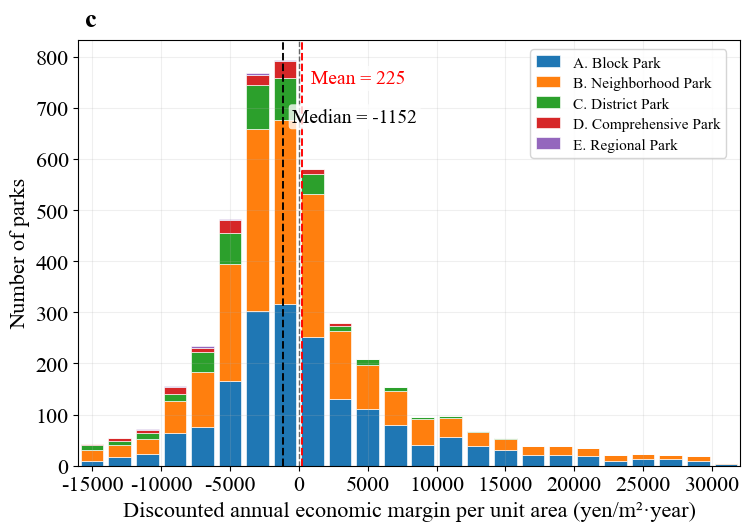

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# 0) CONFIG
# =======================
# 这里换成你新的主情景结果表
SOURCE_DF = pd.read_csv(
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_growth_discounted_2019_50y_r2_b1_om1.csv",
    encoding="utf-8-sig"
).copy()

BIN_W = 2000.0
TEXT_SCALE = 1.55

MAIN_RATE = 0.02
EVAL_YEARS = 50

SAVE_FIG = False
OUT_FIG = "panel_c_discounted_annual_margin_per_m2_updated.png"

TYPE_NAME = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

print("Loaded CSV: main scenario growth-discount results")
print("MAIN_RATE:", MAIN_RATE)

# =======================
# 1) FONT / STYLE
# =======================
plt.rcdefaults()
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

BASE_FONT   = int(round(10 * TEXT_SCALE))
LABEL_FONT  = int(round(10 * TEXT_SCALE))
TICK_FONT   = int(round(10 * TEXT_SCALE))
LEGEND_FONT = int(round(8.0 * TEXT_SCALE))
PANEL_FONT  = int(round(12 * TEXT_SCALE))
LINE_NOTE_FONT = int(round(8.8 * TEXT_SCALE))   # 调大
LINE_VALUE_FONT = int(round(8.8 * TEXT_SCALE))  # 调大

plt.rcParams.update({
    "font.size": BASE_FONT,
    "axes.labelsize": LABEL_FONT,
    "xtick.labelsize": TICK_FONT,
    "ytick.labelsize": TICK_FONT,
    "legend.fontsize": LEGEND_FONT,
})

# =======================
# 2) CHECK REQUIRED COLUMNS
# =======================
need_cols = [
    "park_class",
    "area_m2",
    "npv_50y_growth",
]
miss = [c for c in need_cols if c not in SOURCE_DF.columns]
if miss:
    raise KeyError(f"缺少列：{miss}。请确认你读入的是新的主情景 park-level 结果表。")

d = SOURCE_DF.copy()

d["park_class"] = d["park_class"].astype(str).str.strip()
d["area_m2"] = pd.to_numeric(d["area_m2"], errors="coerce")
d["npv_50y_growth"] = pd.to_numeric(d["npv_50y_growth"], errors="coerce")

d = d[d["park_class"].isin(list("ABCDE"))].copy()
d = d[np.isfinite(d["area_m2"]) & (d["area_m2"] > 0)].copy()
d = d[np.isfinite(d["npv_50y_growth"])].copy()

if len(d) == 0:
    raise ValueError("没有可用于绘图的有效记录。")

print("Rows used:", len(d))

# =======================
# 3) PV FACTOR + ANNUALIZED DISCOUNTED MARGIN
# =======================
pv_factor_50y = np.sum(1.0 / (1.0 + MAIN_RATE) ** np.arange(1, EVAL_YEARS + 1))
print("PV factor (50y):", pv_factor_50y)

d["economic_margin_yen_per_m2"] = (
    d["npv_50y_growth"] / pv_factor_50y
) / d["area_m2"]

x_all = pd.to_numeric(d["economic_margin_yen_per_m2"], errors="coerce")
x_all = x_all[np.isfinite(x_all)]

if x_all.size == 0:
    raise ValueError("economic_margin_yen_per_m2 没有有效值。")

# =======================
# 4) 5%–95% RANGE
# =======================
q05, q95 = np.percentile(x_all.values.astype(float), [5, 95])

inrange = (d["economic_margin_yen_per_m2"] >= q05) & (d["economic_margin_yen_per_m2"] <= q95)
d_in = d[inrange].copy()
excluded = len(d) - len(d_in)

x = d_in["economic_margin_yen_per_m2"].values.astype(float)
mean_x = float(np.mean(x))
median_x = float(np.median(x))

print(f"5%-95% range: [{q05:.2f}, {q95:.2f}]")
print(f"N shown: {len(d_in):,}")
print(f"N excluded: {excluded:,}")
print(f"Mean: {mean_x:.2f}")
print(f"Median: {median_x:.2f}")

# =======================
# 5) FIXED-WIDTH BINS + X RANGE
# =======================
left_data = np.floor(x.min() / BIN_W) * BIN_W
right_data = np.ceil(x.max() / BIN_W) * BIN_W

left = min(left_data, -10000)
right = max(right_data, 15000)

bins = np.arange(left, right + BIN_W, BIN_W)

groups = ["A", "B", "C", "D", "E"]
data_by_g = [
    d_in.loc[d_in["park_class"] == g, "economic_margin_yen_per_m2"].values.astype(float)
    for g in groups
]
legend_labels = [TYPE_NAME[g] for g in groups]

print(f"Histogram x-range: [{left:.0f}, {right:.0f}]")
print(f"Bin width = {BIN_W:.0f}, number of bins = {len(bins)-1}")

# =======================
# 6) PLOT
# =======================
fig, ax = plt.subplots(figsize=(7.8, 5.6), facecolor="white")
ax.set_facecolor("white")

ax.hist(
    data_by_g,
    bins=bins,
    stacked=True,
    rwidth=0.82,
    edgecolor="white",
    linewidth=0.45,
    label=legend_labels,
)

# 0 线
ax.axvline(0, linestyle="--", linewidth=1.0, color="0.4")

# Mean / Median 线
ax.axvline(mean_x, linestyle="--", linewidth=1.45, color="red", alpha=0.95)
ax.axvline(median_x, linestyle="--", linewidth=1.45, color="black", alpha=0.95)

ax.grid(True, alpha=0.20)

ax.set_xlabel("Discounted annual economic margin per unit area (yen/m²·year)")
ax.set_ylabel("Number of parks")

# panel label
ax.text(
    0.01, 1.02, "c",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=PANEL_FONT, fontweight="bold"
)

# 图例
leg = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.2,
    frameon=True,
    framealpha=0.82,
    handlelength=1.4,
    labelspacing=0.35,
    borderpad=0.35,
)
for t in leg.get_texts():
    t.set_fontsize(t.get_fontsize() * 0.92)

# x 轴范围和刻度
ax.set_xlim(left, right)

tick_start = int(np.ceil(left / 5000.0) * 5000)
tick_end = int(np.floor(right / 5000.0) * 5000)
xticks = np.arange(tick_start, tick_end + 1, 5000)
if len(xticks) > 0:
    ax.set_xticks(xticks)

# =======================
# 7) Mean / Median 文本（放在线旁边）
# =======================
y_top = ax.get_ylim()[1]
x_span = right - left
x_offset = x_span * 0.014

close_lines = abs(mean_x - median_x) < x_span * 0.05

if close_lines:
    y_mean = y_top * 0.93
    y_median = y_top * 0.84
else:
    y_mean = y_top * 0.93
    y_median = y_top * 0.93

# Mean
ax.text(
    mean_x + x_offset,
    y_mean,
    f"Mean = {mean_x:.0f}",
    ha="left",
    va="top",
    fontsize=LINE_VALUE_FONT,
    color="red",
    bbox=dict(facecolor="white", alpha=0.78, edgecolor="none", boxstyle="round,pad=0.18")
)

# Median
ax.text(
    median_x + x_offset,
    y_median,
    f"Median = {median_x:.0f}",
    ha="left",
    va="top",
    fontsize=LINE_VALUE_FONT,
    color="black",
    bbox=dict(facecolor="white", alpha=0.78, edgecolor="none", boxstyle="round,pad=0.18")
)

plt.tight_layout()

if SAVE_FIG:
    plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
    print("Saved ->", OUT_FIG)

plt.show()

In [19]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import pandas as pd

t0 = time.perf_counter()

# =========================================================
# 0) PATHS / SETTINGS
# =========================================================
VISIT_FILES = [
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv",
]

COST_XLSX = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/"
    r"成本计算/13_park_medical_and_landprice_with_geo_type_maintenance_2024.xlsx"
)

# ===== 你确认的 E_pop 文件 =====
EPOP_FILE = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/"
    r"program/output/park_exposure_Epop_alltypes.csv"
)

OUT_DIR = (
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "ab_modeling_table_r2_rebuilt.csv")
OUT_XLSX = os.path.join(OUT_DIR, "ab_modeling_table_r2_rebuilt.xlsx")
OUT_DIAG_TXT = os.path.join(OUT_DIR, "ab_modeling_table_r2_rebuilt_diagnostics.txt")

# =========================================================
# 1) MAIN ECONOMIC SETTINGS
# =========================================================
BASE_YEAR = 2019
EVAL_YEARS = 50

# 主口径：2%
DISCOUNT_RATE = 0.02
BENEFIT_GROWTH = 0.02
OM_GROWTH = 0.02

# 收益参数
YEN_PER_STEP_2019 = 0.04056
EXPANSION_FACTOR = 150

# 成本参数
CONSTRUCTION_UNIT_COST_2014 = 12000.0
AREA_IS_HECTARE_WHEN_ONLY_AREA = False

# =========================================================
# 2) CPI TO CONSTANT 2019 JPY
# =========================================================
CPI_2003_2015BASE = 97.2
CPI_2014_2015BASE = 102.8 / 103.6 * 100.0
CPI_2019_2015BASE = 101.8

CONSTRUCTION_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2014_2015BASE
OM_TO_2019_FACTOR = CPI_2019_2015BASE / CPI_2003_2015BASE

# =========================================================
# 3) HELPERS
# =========================================================
def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s

def first_valid(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def numeric_median(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.median()) if len(s) else np.nan

def pick_column(columns, exact_candidates=(), contains_all=(), contains_any=(),
                required=True, label="column"):
    cols = list(columns)
    lower_map = {c.lower(): c for c in cols}

    for cand in exact_candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    for c in cols:
        cl = c.lower()
        ok_all = all(k.lower() in cl for k in contains_all) if contains_all else True
        ok_any = any(k.lower() in cl for k in contains_any) if contains_any else True
        if ok_all and ok_any:
            return c

    if required:
        raise KeyError(f"Cannot find {label}. Available columns:\n{cols}")
    return None

def discounted_payback_with_growth(invest, annual_benefit_0, annual_om_0,
                                   r, g_b, g_om, years=50, max_year_long=500):
    """
    返回：
    - discounted_payback_years_r2
    - discounted_payback_years_50y_r2
    - npv_50y_r2
    - discounted_payback_status_full_r2
    - discounted_payback_status_50y_r2
    - is_finite_payback_r2
    - is_recoup_within_50y_r2
    """
    if not np.isfinite(invest) or not np.isfinite(annual_benefit_0) or not np.isfinite(annual_om_0):
        return np.nan, np.nan, np.nan, "invalid", "invalid", False, False

    if invest <= 0:
        npv_50y = 0.0
        for t in range(1, years + 1):
            benefit_t = annual_benefit_0 * ((1 + g_b) ** (t - 1))
            om_t = annual_om_0 * ((1 + g_om) ** (t - 1))
            net_t = benefit_t - om_t
            npv_50y += net_t / ((1 + r) ** t)
        return 0.0, 0.0, npv_50y, "finite payback", "recouped within 50 years", True, True

    cum_pv = 0.0
    payback_year_50 = np.nan
    npv_50y = -invest

    for t in range(1, years + 1):
        benefit_t = annual_benefit_0 * ((1 + g_b) ** (t - 1))
        om_t = annual_om_0 * ((1 + g_om) ** (t - 1))
        net_t = benefit_t - om_t
        pv_t = net_t / ((1 + r) ** t)

        cum_pv += pv_t
        npv_50y += pv_t

        if pd.isna(payback_year_50) and cum_pv >= invest:
            payback_year_50 = float(t)

    if pd.notna(payback_year_50):
        return payback_year_50, payback_year_50, npv_50y, "finite payback", "recouped within 50 years", True, True

    cum_pv_long = cum_pv
    payback_year_full = np.nan

    for t in range(years + 1, max_year_long + 1):
        benefit_t = annual_benefit_0 * ((1 + g_b) ** (t - 1))
        om_t = annual_om_0 * ((1 + g_om) ** (t - 1))
        net_t = benefit_t - om_t
        pv_t = net_t / ((1 + r) ** t)
        cum_pv_long += pv_t

        if pd.isna(payback_year_full) and cum_pv_long >= invest:
            payback_year_full = float(t)
            break

    if pd.notna(payback_year_full):
        return payback_year_full, np.nan, npv_50y, "finite payback", "not recouped within 50 years", True, False
    else:
        return np.inf, np.nan, npv_50y, "never pay back", "never pay back", False, False

def map_state_full(x):
    if pd.isna(x):
        return "invalid"
    if np.isinf(x):
        return "never"
    return "finite"

def map_state_50y(x):
    if pd.isna(x):
        return "beyond_50y"
    return "within_50y"

# =========================================================
# 4) READ VISIT DATA
# =========================================================
visit_frames = []
for fp in VISIT_FILES:
    df0 = pd.read_csv(fp, low_memory=False)
    visit_frames.append(df0)

visits = pd.concat(visit_frames, ignore_index=True)

osm_col = pick_column(
    visits.columns,
    exact_candidates=("osm_id",),
    contains_any=("osm_id",),
    label="visit osm_id"
)
steps_col = pick_column(
    visits.columns,
    exact_candidates=("steps",),
    contains_any=("steps",),
    label="steps"
)
lat_col = pick_column(
    visits.columns,
    exact_candidates=("Lat", "lat", "latitude"),
    contains_any=("lat",),
    label="lat"
)
lng_col = pick_column(
    visits.columns,
    exact_candidates=("Lng", "lng", "lon", "longitude"),
    contains_any=("lng", "lon"),
    label="lng"
)
area_col = pick_column(
    visits.columns,
    exact_candidates=("area_m2", "area"),
    contains_any=("area",),
    label="area"
)
park_class_col = pick_column(
    visits.columns,
    exact_candidates=("park_class",),
    contains_all=("park", "class"),
    contains_any=("class",),
    required=False,
    label="park_class"
)
park_class_name_col = pick_column(
    visits.columns,
    exact_candidates=("park_class_name",),
    contains_all=("park", "class", "name"),
    contains_any=("class_name", "park_class_name"),
    required=False,
    label="park_class_name"
)

visits = visits.copy()
visits["osm_id_norm"] = norm_osm(visits[osm_col])
visits["steps_num"] = pd.to_numeric(visits[steps_col], errors="coerce")
visits["lat_num"] = pd.to_numeric(visits[lat_col], errors="coerce")
visits["lng_num"] = pd.to_numeric(visits[lng_col], errors="coerce")
visits["area_raw"] = pd.to_numeric(visits[area_col], errors="coerce")

if AREA_IS_HECTARE_WHEN_ONLY_AREA:
    visits["area_m2"] = visits["area_raw"] * 10000.0
else:
    visits["area_m2"] = visits["area_raw"]

agg_dict = {
    "lat_num": "mean",
    "lng_num": "mean",
    "area_m2": numeric_median,
    "steps_num": "sum",
}
if park_class_col is not None:
    agg_dict[park_class_col] = first_valid
if park_class_name_col is not None:
    agg_dict[park_class_name_col] = first_valid

park_agg = (
    visits.loc[visits["osm_id_norm"].notna()]
    .groupby(["osm_id_norm"], dropna=False, as_index=False)
    .agg(agg_dict)
)

park_agg = park_agg.rename(columns={
    "lat_num": "Lat",
    "lng_num": "Lng",
    "steps_num": "steps_sum",
})
if park_class_col is not None and park_class_col in park_agg.columns:
    park_agg = park_agg.rename(columns={park_class_col: "park_class"})
if park_class_name_col is not None and park_class_name_col in park_agg.columns:
    park_agg = park_agg.rename(columns={park_class_name_col: "park_class_name"})

# annual benefit at 2019 price base
park_agg["annual_benefit_yen_2019"] = (
    park_agg["steps_sum"].fillna(0.0) * YEN_PER_STEP_2019 * EXPANSION_FACTOR
)

# =========================================================
# 5) READ COST DATA
# =========================================================
cost = pd.read_excel(COST_XLSX)

cost_osm_col = pick_column(
    cost.columns,
    exact_candidates=("osm_id",),
    contains_any=("osm_id",),
    label="cost osm_id"
)
land_price_col = pick_column(
    cost.columns,
    exact_candidates=("price_fina", "land_price", "price", "unit_land_price"),
    contains_any=("price_fina", "land_price", "price"),
    label="land price"
)
om_unit_col = pick_column(
    cost.columns,
    exact_candidates=("unit_maintenance_yen_per_m2_2024", "maint", "maintenance", "unit_maintenance"),
    contains_any=("maint", "maintenance"),
    label="maintenance unit cost"
)

cost = cost.copy()
cost["osm_id_norm"] = norm_osm(cost[cost_osm_col])
cost["land_price"] = pd.to_numeric(cost[land_price_col], errors="coerce")
cost["om_unit_raw"] = pd.to_numeric(cost[om_unit_col], errors="coerce")

cost_use = cost[["osm_id_norm", "land_price", "om_unit_raw"]].copy()

# =========================================================
# 6) READ EPOP DATA
# =========================================================
epop = pd.read_csv(EPOP_FILE, low_memory=False)

epop_osm_col = pick_column(
    epop.columns,
    exact_candidates=("osm_id_norm", "osm_id"),
    contains_any=("osm_id_norm", "osm_id"),
    label="E_pop osm_id"
)
epop_col = pick_column(
    epop.columns,
    exact_candidates=("E_pop",),
    contains_all=("e", "pop"),
    contains_any=("E_pop", "epop"),
    label="E_pop"
)
epop_per_m2_col = pick_column(
    epop.columns,
    exact_candidates=("E_pop_per_m2",),
    contains_all=("e", "pop", "m2"),
    contains_any=("E_pop_per_m2", "epop_per_m2"),
    required=False,
    label="E_pop_per_m2"
)

epop = epop.copy()
epop["osm_id_norm"] = norm_osm(epop[epop_osm_col])
epop["E_pop"] = pd.to_numeric(epop[epop_col], errors="coerce")

if epop_per_m2_col is not None:
    epop["E_pop_per_m2"] = pd.to_numeric(epop[epop_per_m2_col], errors="coerce")
else:
    epop["E_pop_per_m2"] = np.nan

epop_use = epop[["osm_id_norm", "E_pop", "E_pop_per_m2"]].copy()

# 如果 E_pop 文件同一个公园有重复记录，先聚合
epop_use = (
    epop_use.groupby("osm_id_norm", as_index=False)
    .agg({
        "E_pop": "median",
        "E_pop_per_m2": "median"
    })
)

# =========================================================
# 7) MERGE ALL
# =========================================================
df = park_agg.merge(cost_use, on="osm_id_norm", how="left")
df = df.merge(epop_use, on="osm_id_norm", how="left")

# maintenance cost converted to 2019
df["maint"] = df["om_unit_raw"] * OM_TO_2019_FACTOR

# construction unit cost converted to 2019
df["construction_unit_cost_2019"] = CONSTRUCTION_UNIT_COST_2014 * CONSTRUCTION_TO_2019_FACTOR

df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")

# one-time investment
df["land_cost_2019"] = df["land_price"] * df["area_m2"]
df["construction_cost_2019"] = df["construction_unit_cost_2019"] * df["area_m2"]
df["one_time_investment_2019"] = df["land_cost_2019"] + df["construction_cost_2019"]

# annual O&M cost
df["annual_om_cost_2019"] = df["maint"] * df["area_m2"]

# annual net benefit at 2019 base-year level
df["annual_net_benefit_2019"] = df["annual_benefit_yen_2019"] - df["annual_om_cost_2019"]

# recompute E_pop_per_m2 if missing
mask_epop_per_m2_missing = df["E_pop_per_m2"].isna() & df["E_pop"].notna() & df["area_m2"].gt(0)
df.loc[mask_epop_per_m2_missing, "E_pop_per_m2"] = (
    df.loc[mask_epop_per_m2_missing, "E_pop"] / df.loc[mask_epop_per_m2_missing, "area_m2"]
)

# =========================================================
# 8) DISCOUNTED PAYBACK WITH r = 2%, gB = 2%, gOM = 2%
# =========================================================
results = df.apply(
    lambda row: discounted_payback_with_growth(
        invest=row["one_time_investment_2019"],
        annual_benefit_0=row["annual_benefit_yen_2019"],
        annual_om_0=row["annual_om_cost_2019"],
        r=DISCOUNT_RATE,
        g_b=BENEFIT_GROWTH,
        g_om=OM_GROWTH,
        years=EVAL_YEARS,
        max_year_long=500
    ),
    axis=1,
    result_type="expand"
)

results.columns = [
    "discounted_payback_years_r2",
    "discounted_payback_years_50y_r2",
    "npv_50y_r2",
    "discounted_payback_status_full_r2",
    "discounted_payback_status_50y_r2",
    "is_finite_payback_r2",
    "is_recoup_within_50y_r2",
]

df = pd.concat([df, results], axis=1)

df["payback_state_full_r2"] = df["discounted_payback_years_r2"].apply(map_state_full)
df["payback_state_50y_r2"] = df["discounted_payback_years_50y_r2"].apply(map_state_50y)

# =========================================================
# 9) FINAL COLUMN ORDER
# =========================================================
final_cols = [
    "osm_id_norm",
    "park_class",
    "park_class_name",
    "Lng",
    "Lat",
    "area_m2",
    "land_cost_2019",
    "land_price",
    "annual_om_cost_2019",
    "maint",
    "one_time_investment_2019",
    "annual_benefit_yen_2019",
    "annual_net_benefit_2019",
    "discounted_payback_years_r2",
    "payback_state_full_r2",
    "payback_state_50y_r2",
    "is_finite_payback_r2",
    "is_recoup_within_50y_r2",
    "E_pop",
    "E_pop_per_m2",
    "npv_50y_r2",
    "construction_cost_2019",
    "discounted_payback_years_50y_r2",
    "discounted_payback_status_full_r2",
    "discounted_payback_status_50y_r2",
]

for c in final_cols:
    if c not in df.columns:
        df[c] = np.nan

final_df = df[final_cols].copy()

# =========================================================
# 10) SAVE
# =========================================================
final_df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
final_df.to_excel(OUT_XLSX, index=False)

# =========================================================
# 11) DIAGNOSTICS
# =========================================================
overall_dist = final_df["discounted_payback_status_full_r2"].value_counts(dropna=False)
overall_pct = final_df["discounted_payback_status_full_r2"].value_counts(normalize=True, dropna=False) * 100
overall_show = pd.DataFrame({
    "n": overall_dist,
    "pct": overall_pct.round(2)
})

with open(OUT_DIAG_TXT, "w", encoding="utf-8") as f:
    f.write("=== SETTINGS ===\n")
    f.write(f"BASE_YEAR = {BASE_YEAR}\n")
    f.write(f"EVAL_YEARS = {EVAL_YEARS}\n")
    f.write(f"DISCOUNT_RATE = {DISCOUNT_RATE:.6f}\n")
    f.write(f"BENEFIT_GROWTH = {BENEFIT_GROWTH:.6f}\n")
    f.write(f"OM_GROWTH = {OM_GROWTH:.6f}\n")
    f.write(f"EXPANSION_FACTOR = {EXPANSION_FACTOR}\n")
    f.write(f"YEN_PER_STEP_2019 = {YEN_PER_STEP_2019:.8f}\n\n")

    f.write("=== SOURCE FILES ===\n")
    f.write(f"VISIT_FILES = {VISIT_FILES}\n")
    f.write(f"COST_XLSX   = {COST_XLSX}\n")
    f.write(f"EPOP_FILE   = {EPOP_FILE}\n\n")

    f.write("=== SOURCE COLUMNS ===\n")
    f.write(f"VISIT osm_id          : {osm_col}\n")
    f.write(f"VISIT steps           : {steps_col}\n")
    f.write(f"VISIT Lat             : {lat_col}\n")
    f.write(f"VISIT Lng             : {lng_col}\n")
    f.write(f"VISIT area            : {area_col}\n")
    f.write(f"VISIT park_class      : {park_class_col}\n")
    f.write(f"VISIT park_class_name : {park_class_name_col}\n")
    f.write(f"COST osm_id           : {cost_osm_col}\n")
    f.write(f"COST land_price       : {land_price_col}\n")
    f.write(f"COST maint unit       : {om_unit_col}\n")
    f.write(f"EPOP osm_id           : {epop_osm_col}\n")
    f.write(f"EPOP E_pop            : {epop_col}\n")
    f.write(f"EPOP E_pop_per_m2     : {epop_per_m2_col}\n\n")

    f.write("=== OVERALL DISTRIBUTION ===\n")
    f.write(overall_show.to_string())
    f.write("\n")

print("\n================ 重建完成 ================")
print("输出 CSV :", OUT_CSV)
print("输出 XLSX:", OUT_XLSX)
print("输出 TXT :", OUT_DIAG_TXT)
print("\n总体回本状态分布：")
print(overall_show)

print(f"\nDone in {time.perf_counter() - t0:.1f}s")


================ 重建完成 ================
输出 CSV : /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/ab_modeling_table_r2_rebuilt.csv
输出 XLSX: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/ab_modeling_table_r2_rebuilt.xlsx
输出 TXT : /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/ab_modeling_table_r2_rebuilt_diagnostics.txt

总体回本状态分布：
                                      n    pct
discounted_payback_status_full_r2             
finite payback                     4589  95.15
never pay back                      233   4.83
invalid                               1   0.02

Done in 8.0s
